In [ ]:

# CELL 1 — Imports

import random
import cv2
import numpy as np
import logging
from pathlib import Path
from typing import List, Tuple, Optional
from PIL import Image
import os
os.environ["TORCHDYNAMO_DISABLE"] = "1"
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, f1_score)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

try:
    from numba import njit, prange
    HAS_NUMBA = True
except ImportError:
    HAS_NUMBA = False
    logging.warning("numba not found — pip install numba. Falling back to numpy RLE.")

import time
from tqdm import tqdm

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
log = logging.getLogger(__name__)


SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
print("✓ Imports done.")
print(f"✓ Global seed set to {SEED}")

✓ Imports done.
✓ Global seed set to 42


In [ ]:

# CELL 2 — Chest X-ray (Pneumonia) dataset loading

import numpy as np
from pathlib import Path
from PIL import Image

CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
NUM_CLASSES = len(CLASS_NAMES)
CLASS_MAP   = {name: i for i, name in enumerate(CLASS_NAMES)}

DATA_ROOT = Path(r"D:\cancer-ultra sound\pneumonia_ext\chest_xray\chest_xray")

def load_split(split_dir: Path):
    paths, labels = [], []
    for cls_name in CLASS_NAMES:
        cls_dir = split_dir / cls_name
        if not cls_dir.exists():
            print(f"  ⚠ Missing folder: {cls_dir}")
            continue
        files = list(cls_dir.glob("*.jpeg")) + list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.png"))
        paths.extend(files)
        labels.extend([CLASS_MAP[cls_name]] * len(files))
    return paths, np.array(labels, dtype=np.int64)

print("Scanning chest X-ray folders...")

train_paths, y_train_pool   = load_split(DATA_ROOT / "train")
val_paths,   y_val_pool     = load_split(DATA_ROOT / "val")
test_paths,  y_test_paths_l = load_split(DATA_ROOT / "test")


pool_paths  = train_paths + val_paths
pool_labels = np.concatenate([y_train_pool, y_val_pool])

print(f"\n  train folder : {len(train_paths)} images")
print(f"  val folder   : {len(val_paths)} images  (too small — merged into pool)")
print(f"  test folder  : {len(test_paths)} images  (held out, untouched until final eval)")
print(f"  combined pool: {len(pool_paths)} images")

def load_images(paths):
    """Load grayscale images lazily as object array of variable-size uint8 arrays."""
    imgs = []
    for p in tqdm(paths, desc="  loading"):
        img = np.array(Image.open(p).convert('L'), dtype=np.uint8)
        imgs.append(img)
    return np.array(imgs, dtype=object)

print("\nLoading pool images into memory...")
X_train_raw = load_images(pool_paths)
y_train_raw = pool_labels

print("\nLoading held-out test images into memory...")
X_test_holdout_raw = load_images(test_paths)
y_test_holdout_raw = y_test_paths_l

print(f"\nClasses     : {CLASS_NAMES}")
print(f"Pool total  : {len(X_train_raw)} images")
print(f"  NORMAL    : {(y_train_raw==0).sum()}")
print(f"  PNEUMONIA : {(y_train_raw==1).sum()}")
print(f"Held-out test: {len(X_test_holdout_raw)} images")
print(f"  NORMAL    : {(y_test_holdout_raw==0).sum()}")
print(f"  PNEUMONIA : {(y_test_holdout_raw==1).sum()}")

Scanning chest X-ray folders...

  train folder : 5216 images
  val folder   : 16 images  (too small — merged into pool)
  test folder  : 624 images  (held out, untouched until final eval)
  combined pool: 5232 images

Loading pool images into memory...


  loading: 100%|██████████| 5232/5232 [00:40<00:00, 129.46it/s]



Loading held-out test images into memory...


  loading: 100%|██████████| 624/624 [00:04<00:00, 138.88it/s]


Classes     : ['NORMAL', 'PNEUMONIA']
Pool total  : 5232 images
  NORMAL    : 1349
  PNEUMONIA : 3883
Held-out test: 624 images
  NORMAL    : 234
  PNEUMONIA : 390


In [ ]:
# CELL 4 — Configuration

   
NUM_CLASSES = 2
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
CLASS_MAP   = {name: i for i, name in enumerate(CLASS_NAMES)}
IMAGE_SIZE  = 64   

# --- image / RLE knobs ---
MAX_RUNS       = 4
NEARFIELD_SKIP = 0.0
FARFIELD_SKIP  = 0.0

# --- derived (do not edit) ---
Y_START   = int(IMAGE_SIZE * NEARFIELD_SKIP)
Y_END     = int(IMAGE_SIZE * (1.0 - FARFIELD_SKIP))
CROP_ROWS = Y_END - Y_START
ROW_FEAT  = CROP_ROWS  * MAX_RUNS * 3
COL_FEAT  = IMAGE_SIZE * MAX_RUNS * 3

# --- model architecture knobs ---
CONV_CHANNELS = [16, 32,32]
CONV_KERNEL   = 3
POOL_OUT      = 2
FC_HIDDEN     = 128
FC_DROPOUT    = 0.05
CONV_DROPOUT  = 0.1

# --- training knobs ---
SEED             = 42
_aug_rng = np.random.default_rng(SEED)
BATCH_SIZE       = 1024   
EPOCHS           = 100    
LR               = 3e-3
WEIGHT_DECAY     = 5e-3
PATIENCE         = 30
DEVICE           = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(SEED) 
# --- loss / imbalance ---
IMBALANCE_STRATEGY = "class_weight"
LOSS_FN            = "focal"
FOCAL_GAMMA        = 2.0
THRESH_K           =0.2

# --- augmentation --- 
AUG_PARAMS = dict(
    flip_prob    = 0.0,
    rotate_prob  = 0.0,
    rotate_limit = 0.0,
)

NUM_DATALOADER_WORKERS = 0

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark     = True

print("✓ Configuration set.")
print(f"  Device         : {DEVICE}")
print(f"  IMAGE_SIZE     : {IMAGE_SIZE}  MAX_RUNS={MAX_RUNS}  CROP_ROWS={CROP_ROWS}")
print(f"  ROW_FEAT       : {ROW_FEAT}   COL_FEAT={COL_FEAT}   TOTAL={ROW_FEAT+COL_FEAT}")
print(f"  NUM_CLASSES    : {NUM_CLASSES}  → {CLASS_NAMES}")
print(f"  BATCH={BATCH_SIZE}  LR={LR}  WD={WEIGHT_DECAY}  EPOCHS={EPOCHS}  PATIENCE={PATIENCE}")
print(f"  AUG: flip={AUG_PARAMS['flip_prob']}  rotate={AUG_PARAMS['rotate_prob']}")

✓ Configuration set.
  Device         : cuda
  IMAGE_SIZE     : 64  MAX_RUNS=4  CROP_ROWS=64
  ROW_FEAT       : 768   COL_FEAT=768   TOTAL=1536
  NUM_CLASSES    : 2  → ['NORMAL', 'PNEUMONIA']
  BATCH=1024  LR=0.003  WD=0.005  EPOCHS=100  PATIENCE=30
  AUG: flip=0.0  rotate=0.0


In [ ]:
# CELL 5 — RLE helpers + augmentation


if HAS_NUMBA:
    @njit(parallel=True, cache=True)
    def _rle_numba(binary: np.ndarray, img_u8: np.ndarray, max_runs: int) -> np.ndarray:
        H, W = binary.shape
        out  = np.zeros((H, max_runs * 3), dtype=np.float32)
        for i in prange(H):
            in_run = False
            start  = 0
            run_n  = 0
            for j in range(W):
                val = binary[i, j]
                if val == 1 and not in_run:
                    start  = j
                    in_run = True
                elif val == 0 and in_run:
                    if run_n < max_runs:
                        length = j - start
                        total  = np.float32(0.0)
                        for k in range(length):
                            total += np.float32(img_u8[i, start + k]) 
                        out[i, run_n * 3]     = np.float32(start)  / np.float32(W)
                        out[i, run_n * 3 + 1] = np.float32(length) / np.float32(W)
                        out[i, run_n * 3 + 2] = (total / np.float32(length)) / np.float32(255.0)
                        run_n += 1
                    in_run = False
            if in_run and run_n < max_runs:
                length = W - start
                total  = np.float32(0.0)
                for k in range(length):
                    total += np.float32(img_u8[i, start + k])         
                out[i, run_n * 3]     = np.float32(start)  / np.float32(W)
                out[i, run_n * 3 + 1] = np.float32(length) / np.float32(W)
                out[i, run_n * 3 + 2] = (total / np.float32(length)) / np.float32(255.0)
        return out

    def vectorized_rle(binary: np.ndarray,
                       img_u8: np.ndarray,
                       max_runs: int = MAX_RUNS) -> np.ndarray:
        return _rle_numba(np.ascontiguousarray(binary),
                          np.ascontiguousarray(img_u8.astype(np.uint8)),
                          max_runs)

else:
    def vectorized_rle(binary: np.ndarray,
                       img_u8: np.ndarray,
                       max_runs: int = MAX_RUNS) -> np.ndarray:
        H, W   = binary.shape
        out    = np.zeros((H, max_runs * 3), dtype=np.float32)
        padded = np.concatenate([
            np.zeros((H, 1), dtype=np.int8),
            binary.astype(np.int8),
            np.zeros((H, 1), dtype=np.int8),
        ], axis=1)
        diff = np.diff(padded, axis=1)
        img_f = img_u8.astype(np.float32)          
        for i in range(H):
            row    = diff[i]
            starts = np.where(row ==  1)[0]
            ends   = np.where(row == -1)[0]
            n      = min(len(starts), max_runs)
            if n == 0:
                continue
            lengths = (ends[:n] - starts[:n]).astype(np.float32)
            out[i, 0:n*3:3] = starts[:n].astype(np.float32) / W
            out[i, 1:n*3:3] = lengths / W
            for k in range(n):
                s = int(starts[k])
                l = int(lengths[k])
                out[i, k*3 + 2] = img_f[i, s:s+l].mean() / 255.0   
        return out


def _rle_from_array(img_arr: np.ndarray) -> np.ndarray:
    img_f     = img_arr.astype(np.float32)
    mean      = img_f.mean()
    std       = img_f.std()
    threshold = mean + THRESH_K * std
    binary    = (img_f > threshold).astype(np.uint8)
    img_u8    = img_arr.astype(np.uint8)

    rle_row = vectorized_rle(binary,
                             img_u8,
                             MAX_RUNS)
    rle_col = vectorized_rle(np.ascontiguousarray(binary.T),
                             np.ascontiguousarray(img_u8.T),
                             MAX_RUNS)
    return np.concatenate([rle_row.flatten(), rle_col.flatten()])


def _augment(img: np.ndarray) -> list:
    results = []
    if AUG_PARAMS['flip_prob'] > 0 and _aug_rng.random() < AUG_PARAMS['flip_prob']:
        results.append(np.fliplr(img))
    if AUG_PARAMS['rotate_prob'] > 0 and _aug_rng.random() < AUG_PARAMS['rotate_prob']:
        h, w  = img.shape
        angle = _aug_rng.uniform(-AUG_PARAMS['rotate_limit'],
                                  AUG_PARAMS['rotate_limit'])
        M     = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
        results.append(cv2.warpAffine(img, M, (w, h),
                                      flags      = cv2.INTER_LINEAR,
                                      borderMode = cv2.BORDER_CONSTANT,
                                      borderValue= 0))
    return results

print("✓ RLE helpers defined.")

✓ RLE helpers defined.


  Using X_train_raw[0]
  Resized: (1858, 2090) → (64, 64)

  SINGLE IMAGE CONFIG CHECK
  IMAGE_SIZE     : 64
  MAX_RUNS       : 4
  THRESH_K       : 0.2
  NEARFIELD_SKIP : 0.0  →  Y_START=0
  FARFIELD_SKIP  : 0.0   →  Y_END=64
  CROP_ROWS      : 64
  Features/run   : 3  (start, length, avg_intensity)
  Total features : 1536  (expected ROW_FEAT+COL_FEAT=1536)

  Pixel stats (after resize+crop):
    mean      : 128.91
    std       : 61.42
    threshold : 141.19  (mean + 0.2*std)
    foreground pixels (binary=1): 1931 / 4096  (47.1%)

  RLE run usage (capped at MAX_RUNS=4):
    Row — max runs used : 4  / MAX_RUNS=4  (CLIPPING ✗ — increase MAX_RUNS)
    Col — max runs used : 4  / MAX_RUNS=4  (CLIPPING ✗ — increase MAX_RUNS)
    Avg runs/row        : 3.19
    Avg runs/col        : 2.39

  TRUE run usage (uncapped, ignores MAX_RUNS):
    Row — true max runs : 6  (CLIPPING 10/64 rows)
    Col — true max runs : 8  (CLIPPING 14/64 cols)
    Avg true runs/row   : 3.36
    Avg true runs/col   : 

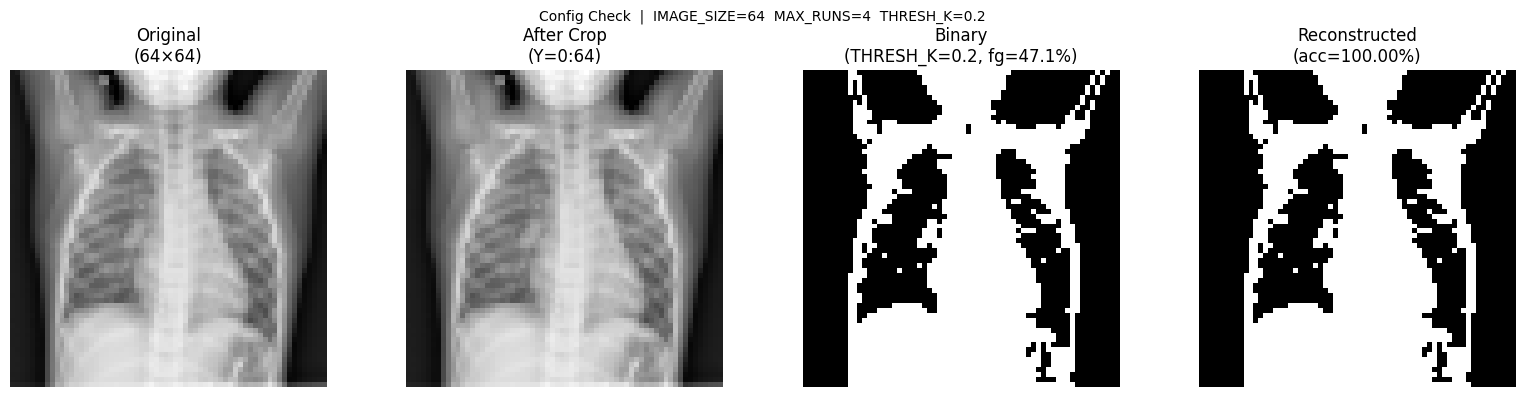

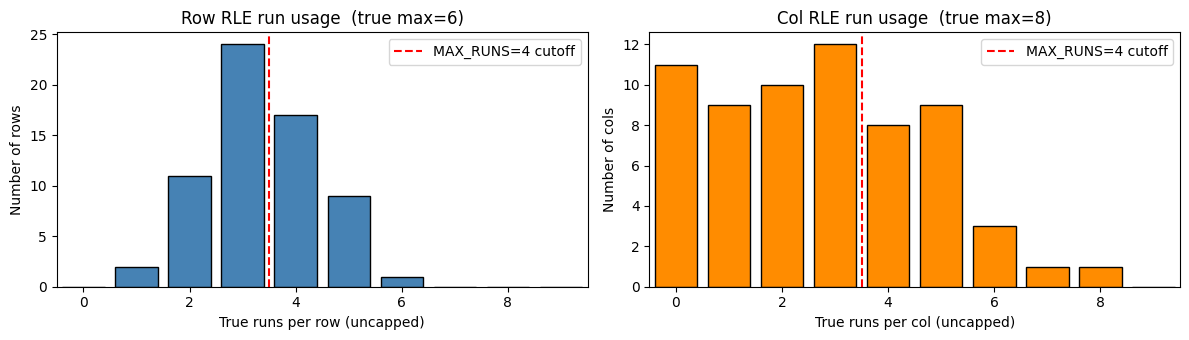

In [ ]:

# CELL 4B — Single Image Reconstruction Check

import matplotlib.pyplot as plt
import cv2

def true_run_count(binary_line: np.ndarray) -> int:
    """Count actual number of foreground runs in a 1D binary array, no MAX_RUNS cap."""
    padded = np.concatenate([[0], binary_line.astype(np.int8), [0]])
    diff   = np.diff(padded)
    return int((diff == 1).sum())


def check_single_image_reconstruction(img_input=None, show_stats=True):

    if img_input is None:
        if 'X_train_raw' in dir() or 'X_train_raw' in globals():
            img_input = X_train_raw[0]
            print(f"  Using X_train_raw[0]")
        else:
            print("  ERROR: No image source found. Pass an image array directly.")
            return

    img = np.array(img_input, dtype=np.uint8)

    original_shape = img.shape
    if img.shape[0] != IMAGE_SIZE or img.shape[1] != IMAGE_SIZE:
        img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)
        print(f"  Resized: {original_shape} → {img.shape}")
    else:
        print(f"  Shape OK: {img.shape} (no resize needed)")

    img_cropped = img[Y_START:Y_END, :]
    img_u8      = img_cropped.astype(np.uint8)          

    img_f     = img_cropped.astype(np.float32)
    mean_val  = img_f.mean()
    std_val   = img_f.std()
    threshold = mean_val + THRESH_K * std_val
    binary    = (img_f > threshold).astype(np.uint8)    

    # ── RLE extraction — pass img_u8 for intensity
    rle_row = vectorized_rle(binary,                          img_u8,   MAX_RUNS)
    rle_col = vectorized_rle(np.ascontiguousarray(binary.T), np.ascontiguousarray(img_u8.T), MAX_RUNS)
    raw_features = np.concatenate([rle_row.flatten(), rle_col.flatten()])

    # ── reconstruction — index is now *3 instead of *2 
    H, W          = img_cropped.shape
    reconstructed = np.zeros((H, W), dtype=np.uint8)

    for i in range(H):
        for j in range(MAX_RUNS):
            start  = int(rle_row[i, j * 3]     * W)
            length = int(rle_row[i, j * 3 + 1] * W)
            if length > 0:
                reconstructed[i, start:min(start + length, W)] = 1

    for j in range(W):
        for k in range(MAX_RUNS):
            start  = int(rle_col[j, k * 3]     * H)
            length = int(rle_col[j, k * 3 + 1] * H)
            if length > 0:
                reconstructed[start:min(start + length, H), j] = 1

    recon_acc = (binary == reconstructed).mean()

    # ── run statistics — CAPPED (as encoded, respects MAX_RUNS)
    runs_per_row = []
    for i in range(H):
        used = sum(1 for j in range(MAX_RUNS) if rle_row[i, j * 3 + 1] > 0)
        runs_per_row.append(used)
    runs_per_row = np.array(runs_per_row)

    runs_per_col = []
    for j in range(W):
        used = sum(1 for k in range(MAX_RUNS) if rle_col[j, k * 3 + 1] > 0)
        runs_per_col.append(used)
    runs_per_col = np.array(runs_per_col)

    # ── run statistics — TRUE (uncapped, ignores MAX_RUNS) 
    true_runs_per_row = np.array([true_run_count(binary[i, :]) for i in range(H)])
    true_runs_per_col = np.array([true_run_count(binary[:, j]) for j in range(W)])

    non_zero_ratio = (raw_features > 0.001).mean()

    if show_stats:
        print(f"\n{'='*55}")
        print(f"  SINGLE IMAGE CONFIG CHECK")
        print(f"{'='*55}")
        print(f"  IMAGE_SIZE     : {IMAGE_SIZE}")
        print(f"  MAX_RUNS       : {MAX_RUNS}")
        print(f"  THRESH_K       : {THRESH_K}")
        print(f"  NEARFIELD_SKIP : {NEARFIELD_SKIP}  →  Y_START={Y_START}")
        print(f"  FARFIELD_SKIP  : {FARFIELD_SKIP}   →  Y_END={Y_END}")
        print(f"  CROP_ROWS      : {CROP_ROWS}")
        print(f"  Features/run   : 3  (start, length, avg_intensity)")
        print(f"  Total features : {len(raw_features)}  "
              f"(expected ROW_FEAT+COL_FEAT={ROW_FEAT+COL_FEAT})")
        print(f"\n  Pixel stats (after resize+crop):")
        print(f"    mean      : {mean_val:.2f}")
        print(f"    std       : {std_val:.2f}")
        print(f"    threshold : {threshold:.2f}  (mean + {THRESH_K}*std)")
        print(f"    foreground pixels (binary=1): "
              f"{binary.sum()} / {binary.size}  "
              f"({binary.mean():.1%})")
        print(f"\n  RLE run usage (capped at MAX_RUNS={MAX_RUNS}):")
        print(f"    Row — max runs used : {runs_per_row.max()}  "
              f"/ MAX_RUNS={MAX_RUNS}  "
              f"({'OK ✓' if runs_per_row.max() < MAX_RUNS else 'CLIPPING ✗ — increase MAX_RUNS'})")
        print(f"    Col — max runs used : {runs_per_col.max()}  "
              f"/ MAX_RUNS={MAX_RUNS}  "
              f"({'OK ✓' if runs_per_col.max() < MAX_RUNS else 'CLIPPING ✗ — increase MAX_RUNS'})")
        print(f"    Avg runs/row        : {runs_per_row.mean():.2f}")
        print(f"    Avg runs/col        : {runs_per_col.mean():.2f}")
        print(f"\n  TRUE run usage (uncapped, ignores MAX_RUNS):")
        print(f"    Row — true max runs : {true_runs_per_row.max()}  "
              f"({'no clipping' if true_runs_per_row.max() <= MAX_RUNS else f'CLIPPING {(true_runs_per_row > MAX_RUNS).sum()}/{H} rows'})")
        print(f"    Col — true max runs : {true_runs_per_col.max()}  "
              f"({'no clipping' if true_runs_per_col.max() <= MAX_RUNS else f'CLIPPING {(true_runs_per_col > MAX_RUNS).sum()}/{W} cols'})")
        print(f"    Avg true runs/row   : {true_runs_per_row.mean():.2f}")
        print(f"    Avg true runs/col   : {true_runs_per_col.mean():.2f}")
        print(f"\n  Non-zero feature ratio : {non_zero_ratio:.2%}  "
              f"({'OK ✓' if 0.05 < non_zero_ratio < 0.8 else 'CHECK THRESH_K ✗'})")
        print(f"  Reconstruction accuracy: {recon_acc:.2%}  "
              f"({'OK ✓' if recon_acc > 0.85 else 'LOW ✗ — check MAX_RUNS / THRESH_K'})")

        print(f"\n  DIAGNOSIS:")
        issues = 0
        if binary.mean() < 0.02:
            print(f"  ✗ Binary image almost empty — THRESH_K={THRESH_K} too low, increase it")
            issues += 1
        if binary.mean() > 0.95:
            print(f"  ✗ Binary image almost full  — THRESH_K={THRESH_K} too high, decrease it")
            issues += 1
        if true_runs_per_row.max() > MAX_RUNS:
            print(f"  ✗ Row runs clipping — true max={true_runs_per_row.max()} > MAX_RUNS={MAX_RUNS} — increase MAX_RUNS")
            issues += 1
        if true_runs_per_col.max() > MAX_RUNS:
            print(f"  ✗ Col runs clipping — true max={true_runs_per_col.max()} > MAX_RUNS={MAX_RUNS} — increase MAX_RUNS")
            issues += 1
        if recon_acc < 0.85:
            print(f"  ✗ Reconstruction < 85% — likely MAX_RUNS too small")
            issues += 1
        if non_zero_ratio < 0.05:
            print(f"  ✗ Too sparse — image may be nearly blank after binarization")
            issues += 1
        if issues == 0:
            print(f"  ✓ All checks passed — config looks good for full extraction")
        print(f"{'='*55}")

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(img,           cmap='gray'); axes[0].set_title(f'Original\n({IMAGE_SIZE}×{IMAGE_SIZE})');              axes[0].axis('off')
    axes[1].imshow(img_cropped,   cmap='gray'); axes[1].set_title(f'After Crop\n(Y={Y_START}:{Y_END})');                  axes[1].axis('off')
    axes[2].imshow(binary,        cmap='gray'); axes[2].set_title(f'Binary\n(THRESH_K={THRESH_K}, fg={binary.mean():.1%})'); axes[2].axis('off')
    axes[3].imshow(reconstructed, cmap='gray'); axes[3].set_title(f'Reconstructed\n(acc={recon_acc:.2%})');                axes[3].axis('off')
    plt.suptitle(f'Config Check  |  IMAGE_SIZE={IMAGE_SIZE}  MAX_RUNS={MAX_RUNS}  THRESH_K={THRESH_K}', fontsize=10)
    plt.tight_layout()
    plt.show()

    # ── bar charts: TRUE run counts, x-axis up to 20
    PLOT_MAX = min(20, max(true_runs_per_row.max(), true_runs_per_col.max(), MAX_RUNS) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    axes[0].bar(range(PLOT_MAX + 1),
                np.bincount(true_runs_per_row, minlength=PLOT_MAX + 1)[:PLOT_MAX + 1],
                color='steelblue', edgecolor='black')
    axes[0].set_xlabel('True runs per row (uncapped)')
    axes[0].set_ylabel('Number of rows')
    axes[0].set_title(f'Row RLE run usage  (true max={true_runs_per_row.max()})')
    axes[0].axvline(MAX_RUNS - 0.5, color='red', linestyle='--', label=f'MAX_RUNS={MAX_RUNS} cutoff')
    axes[0].set_xlim(-0.5, PLOT_MAX + 0.5)
    axes[0].legend()

    axes[1].bar(range(PLOT_MAX + 1),
                np.bincount(true_runs_per_col, minlength=PLOT_MAX + 1)[:PLOT_MAX + 1],
                color='darkorange', edgecolor='black')
    axes[1].set_xlabel('True runs per col (uncapped)')
    axes[1].set_ylabel('Number of cols')
    axes[1].set_title(f'Col RLE run usage  (true max={true_runs_per_col.max()})')
    axes[1].axvline(MAX_RUNS - 0.5, color='red', linestyle='--', label=f'MAX_RUNS={MAX_RUNS} cutoff')
    axes[1].set_xlim(-0.5, PLOT_MAX + 0.5)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {
        'recon_accuracy'    : recon_acc,
        'non_zero_ratio'    : non_zero_ratio,
        'max_row_runs'      : runs_per_row.max(),
        'max_col_runs'      : runs_per_col.max(),
        'true_max_row_runs' : true_runs_per_row.max(),
        'true_max_col_runs' : true_runs_per_col.max(),
        'fg_ratio'          : binary.mean(),
        'threshold'         : threshold,
        'feature_dim'       : len(raw_features),
    }


config_check = check_single_image_reconstruction()

In [ ]:

# CELL 6 — Feature extraction + caching  (Pneumonia — train/val split + real test)

from sklearn.model_selection import train_test_split

CACHE_DIR       = Path("./cache_pneumonia")
CACHE_DIR.mkdir(exist_ok=True)
FORCE_RECOMPUTE = True


def extract_sequential(images: np.ndarray,
                        labels: np.ndarray,
                        is_train: bool) -> Tuple[list, list]:
    feats, out_labels = [], []
    desc = "train" if is_train else "other"
    for img, label in tqdm(zip(images, labels), total=len(images),
                           desc=f"  RLE {desc}"):
        img = img.astype(np.uint8)
        if img.shape[0] != IMAGE_SIZE or img.shape[1] != IMAGE_SIZE:
            img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE),
                             interpolation=cv2.INTER_AREA)
        img = img[Y_START:Y_END, :]
        feats.append(_rle_from_array(img).astype(np.float32))
        out_labels.append(int(label))
        if is_train:
            for aug in _augment(img):
                feats.append(_rle_from_array(aug).astype(np.float32))
                out_labels.append(int(label))
    return feats, out_labels


cache_paths = {
    'X_train': CACHE_DIR / "X_train.npy",
    'y_train': CACHE_DIR / "y_train.npy",
    'X_test' : CACHE_DIR / "X_test.npy",
    'y_test' : CACHE_DIR / "y_test.npy",
}

if not FORCE_RECOMPUTE and all(f.exists() for f in cache_paths.values()):
    print("Loading features from cache...")
    X_train = np.load(cache_paths['X_train'])
    y_train = np.load(cache_paths['y_train'])
    X_test  = np.load(cache_paths['X_test'])
    y_test  = np.load(cache_paths['y_test'])
    print(f"  Train: {X_train.shape}  Test: {X_test.shape}")

    expected_dim = ROW_FEAT + COL_FEAT
    if X_train.shape[1] != expected_dim:
        raise ValueError(
            f"Cached feature dim ({X_train.shape[1]}) does not match current "
            f"config (expected {expected_dim} = ROW_FEAT {ROW_FEAT} + COL_FEAT {COL_FEAT}). "
            f"Set FORCE_RECOMPUTE=True and re-run."
        )

else:
    print("Extracting RLE features from scratch...")
    print(f"  flip={AUG_PARAMS['flip_prob']}  rotate={AUG_PARAMS['rotate_prob']}  "
          f"MAX_RUNS={MAX_RUNS}  THRESH_K={THRESH_K}")

    # ── X_train_raw is the train+val POOL from Cell 2, NOT the real test set.
    # ── A real, separate test set exists: X_test_holdout_raw / y_test_holdout_raw.
    # ── This split is train-vs-val ONLY.
    idx_tr, idx_va = train_test_split(
        np.arange(len(X_train_raw)),
        test_size    = 0.2,
        stratify     = y_train_raw,
        random_state = SEED,
    )
    print(f"  Pool split → train={len(idx_tr)}  val={len(idx_va)}")
    print(f"  (real held-out test set: {len(X_test_holdout_raw)} images, untouched)")

    print(f"\n[1/3] Train ({len(idx_tr)} images)...")
    tf, tl = extract_sequential(X_train_raw[idx_tr], y_train_raw[idx_tr], True)

    print(f"\n[2/3] Val ({len(idx_va)} images)...")
    tfv, tlv = extract_sequential(X_train_raw[idx_va], y_train_raw[idx_va], False)

    print(f"\n[3/3] Real test set ({len(X_test_holdout_raw)} images)...")
    tft, tlt = extract_sequential(X_test_holdout_raw, y_test_holdout_raw, False)

    print("\nCombining + saving...")
    X_train = np.array(tf,  dtype=np.float32)
    y_train = np.array(tl,  dtype=np.int64)
    X_val   = np.array(tfv, dtype=np.float32)
    y_val   = np.array(tlv, dtype=np.int64)
    X_test  = np.array(tft, dtype=np.float32)
    y_test  = np.array(tlt, dtype=np.int64)

    np.save(cache_paths['X_train'], X_train)
    np.save(cache_paths['y_train'], y_train)
    np.save(CACHE_DIR / "X_val.npy", X_val)
    np.save(CACHE_DIR / "y_val.npy", y_val)
    np.save(cache_paths['X_test'],  X_test)
    np.save(cache_paths['y_test'],  y_test)

print(f"\n✓ Features ready.")
print(f"  Train samples : {len(X_train)}")
print(f"  Test  samples : {len(X_test)}  (real held-out test folder)")
print("    " + "  ".join(f"{CLASS_NAMES[c]}={int((y_train==c).sum())}"
                          for c in range(NUM_CLASSES)))
print(f"  Feature dim   : {X_train.shape[1]}  (expected {ROW_FEAT + COL_FEAT})")
print(f"  Memory        : {X_train.nbytes/1024**2:.1f} MB train  "
      f"{X_test.nbytes/1024**2:.1f} MB test")

Extracting RLE features from scratch...
  flip=0.0  rotate=0.0  MAX_RUNS=4  THRESH_K=0.2
  Pool split → train=4185  val=1047
  (real held-out test set: 624 images, untouched)

[1/3] Train (4185 images)...


  RLE train: 100%|██████████| 4185/4185 [00:49<00:00, 83.86it/s] 



[2/3] Val (1047 images)...


  RLE other: 100%|██████████| 1047/1047 [00:14<00:00, 73.52it/s]



[3/3] Real test set (624 images)...


  RLE other: 100%|██████████| 624/624 [00:09<00:00, 66.44it/s] 



Combining + saving...

✓ Features ready.
  Train samples : 4185
  Test  samples : 624  (real held-out test folder)
    NORMAL=1079  PNEUMONIA=3106
  Feature dim   : 1536  (expected 1536)
  Memory        : 24.5 MB train  3.7 MB test


In [ ]:
# CELL 7 — Feature normalization  (Pneumonia — train/val/test)

def normalize_features(X_tr, X_va, X_te, eps=1e-2):
    std  = X_tr.std(axis=0)
    dead = std < eps

    std_safe       = std.copy()
    std_safe[dead] = 1.0

    X_tr_n = (X_tr / std_safe).astype(np.float32)
    X_va_n = (X_va / std_safe).astype(np.float32)
    X_te_n = (X_te / std_safe).astype(np.float32)

    X_tr_n[:, dead] = 0.0
    X_va_n[:, dead] = 0.0
    X_te_n[:, dead] = 0.0

    print(f"  Total features   : {len(std)}")
    print(f"  Dead columns     : {dead.sum()}  (std < {eps})")
    print(f"  Live columns     : {(~dead).sum()}")
    print(f"  Std range (live) : [{std[~dead].min():.4f}, {std[~dead].max():.4f}]")

    return X_tr_n, X_va_n, X_te_n, std_safe


# ── save raw copies BEFORE normalizing 
X_train_raw_feats = X_train.copy()
X_val_raw_feats   = X_val.copy()
X_test_raw_feats  = X_test.copy()

# ── normalize — fit on train only, apply to val and test 
X_train_n, X_val_n, X_test_n, feat_std = normalize_features(X_train, X_val, X_test)
np.save(CACHE_DIR / "feat_std.npy", feat_std)

# ── sanity check 
live = feat_std >= 1e-2
print(f"\nSanity check X_train_n (live columns only):")
print(f"  mean : {X_train_n[:, live].mean():.4f}")
print(f"  std  : {X_train_n[:, live].std():.4f}")
print(f"  min  : {X_train_n[:, live].min():.4f}")
print(f"  max  : {X_train_n[:, live].max():.4f}")
print(f"\nSanity check X_train_raw_feats:")
print(f"  mean : {X_train_raw_feats.mean():.4f}")
print(f"  max  : {X_train_raw_feats.max():.4f}     (must be <= 1.0)")
print(f"\nShapes:")
print(f"  Train : {X_train_n.shape}")
print(f"  Val   : {X_val_n.shape}")
print(f"  Test  : {X_test_n.shape}")

  Total features   : 1536
  Dead columns     : 15  (std < 0.01)
  Live columns     : 1521
  Std range (live) : [0.0102, 0.4381]

Sanity check X_train_n (live columns only):
  mean : 1.5061
  std  : 2.0159
  min  : 0.0000
  max  : 53.9266

Sanity check X_train_raw_feats:
  mean : 0.2430
  max  : 1.0000     (must be <= 1.0)

Shapes:
  Train : (4185, 1536)
  Val   : (1047, 1536)
  Test  : (624, 1536)


RLE FEATURE QUALITY ASSESSMENT

1. BASIC STATISTICS
--------------------------------------------------
  Train shape    : (4185, 1536)
  Test shape     : (624, 1536)
  Feature dtype  : float32
  Memory (train) : 24.52 MB

  Per-feature statistics (normalized):
    Mean : [0.0000, 7.4787]
    Std  : [0.0000, 1.0000]
    Min  : [0.0000, 3.7930]
    Max  : [0.0000, 53.9266]

  Sparsity (from raw RLE features):
    Avg non-zero ratio : 59.28%
    Std non-zero ratio : 7.56%
    Min non-zero ratio : 27.28%
    Max non-zero ratio : 86.07%

2. CLASS SEPARABILITY
--------------------------------------------------
  Between-class variance : 42.8943
  Within-class variance  : 0.9252
  Ratio (B/W)            : 46.36

  Class mean feature norms:
    NORMAL         : 94.6257
    PNEUMONIA      : 89.3370

3. PCA VISUALIZATION
--------------------------------------------------
  Explained variance:
    PC1    : 8.70%
    PC2    : 3.80%
    Top 5  : 19.17%
    Top 10 : 26.03%
    Top 20 : 32.94%


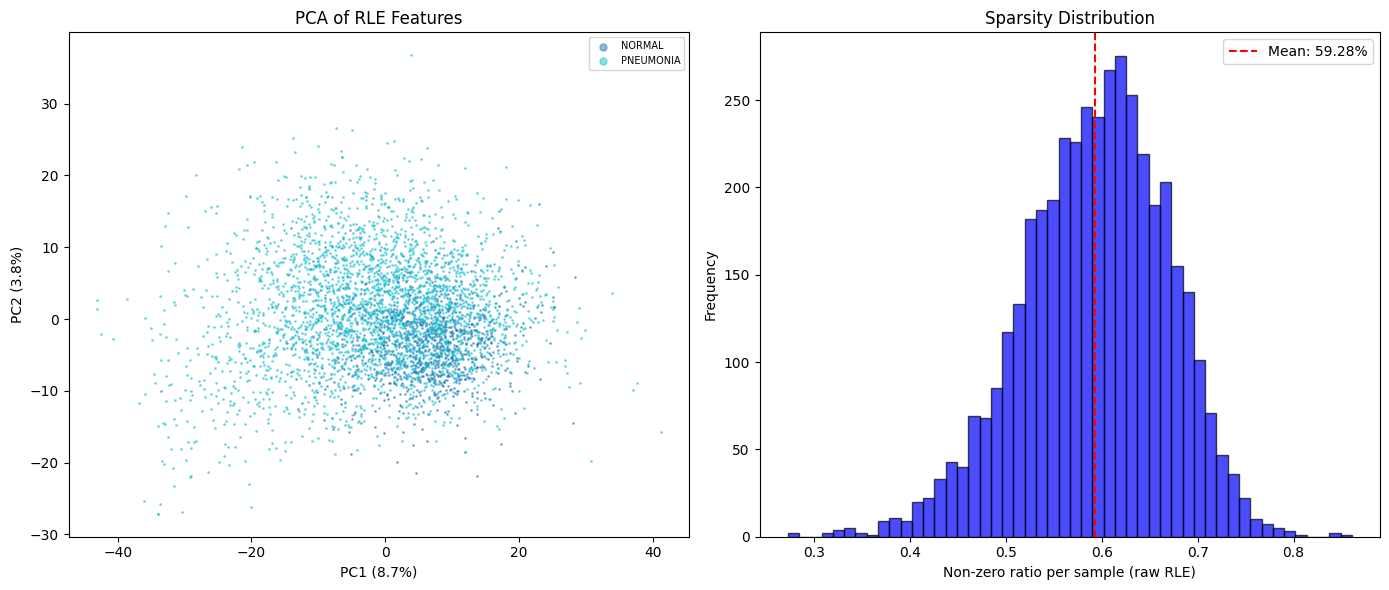


4. FEATURE IMPORTANCE (Top 10 by variance)
--------------------------------------------------
     1. Feature 1211  branch=col  run_pos=11  type=intensity  var=1.0001
     2. Feature  847  branch=col  run_pos=7  type=length  var=1.0001
     3. Feature  563  branch=row  run_pos=11  type=intensity  var=1.0001
     4. Feature  503  branch=row  run_pos=11  type=intensity  var=1.0001
     5. Feature  539  branch=row  run_pos=11  type=intensity  var=1.0001
     6. Feature  873  branch=col  run_pos=9  type=start  var=1.0001
     7. Feature  752  branch=row  run_pos=8  type=intensity  var=1.0001
     8. Feature  753  branch=row  run_pos=9  type=start  var=1.0001
     9. Feature  764  branch=row  run_pos=8  type=intensity  var=1.0001
    10. Feature 1153  branch=col  run_pos=1  type=length  var=1.0001

5. RECONSTRUCTION TEST (first test image)
--------------------------------------------------


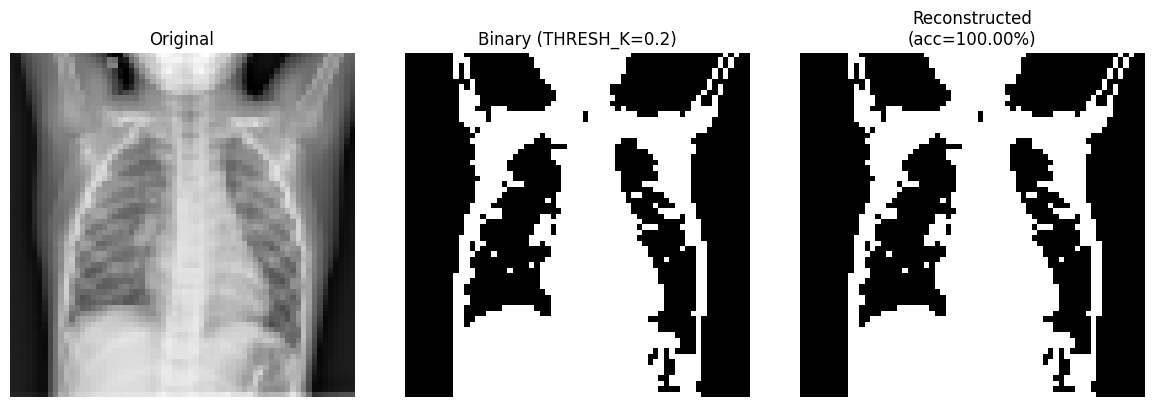

  Threshold              : 141.19  (mean + 0.2*std)
  Reconstruction accuracy: 100.00%
  Feature dim            : 1536

6. CLASS DISTRIBUTION IN FEATURE SPACE
--------------------------------------------------


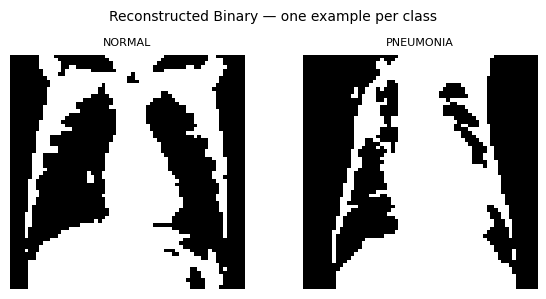


ASSESSMENT SUMMARY
  ✓ Features have meaningful variance
  ✓ Good class separability (B/W > 1.0)
  ✓ Good reconstruction (> 70%)
  ✓ Reasonable sparsity (5–80% non-zero)
  ✗ Low PCA variance — features may be noisy

  OVERALL QUALITY : 4/5
  ★ Excellent!


In [ ]:

# RLE Feature Quality Assessment

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def assess_rle_features(X_train_norm, y_train, X_test_norm, y_test,
                        X_train_raw_feats, X_test_raw_feats,
                        class_names=CLASS_NAMES):

    print("=" * 70)
    print("RLE FEATURE QUALITY ASSESSMENT")
    print("=" * 70)

    # -------------------------------------------------------------------------
    # 1. Basic statistics
    # -------------------------------------------------------------------------
    print("\n1. BASIC STATISTICS")
    print("-" * 50)
    print(f"  Train shape    : {X_train_norm.shape}")
    print(f"  Test shape     : {X_test_norm.shape}")
    print(f"  Feature dtype  : {X_train_norm.dtype}")
    print(f"  Memory (train) : {X_train_norm.nbytes / 1024**2:.2f} MB")

    mean_per_feat = X_train_norm.mean(axis=0)
    std_per_feat  = X_train_norm.std(axis=0)
    min_per_feat  = X_train_norm.min(axis=0)
    max_per_feat  = X_train_norm.max(axis=0)

    print(f"\n  Per-feature statistics (normalized):")
    print(f"    Mean : [{mean_per_feat.min():.4f}, {mean_per_feat.max():.4f}]")
    print(f"    Std  : [{std_per_feat.min():.4f}, {std_per_feat.max():.4f}]")
    print(f"    Min  : [{min_per_feat.min():.4f}, {min_per_feat.max():.4f}]")
    print(f"    Max  : [{max_per_feat.min():.4f}, {max_per_feat.max():.4f}]")

    non_zero_ratio = (X_train_raw_feats > 0.001).mean(axis=1)
    print(f"\n  Sparsity (from raw RLE features):")
    print(f"    Avg non-zero ratio : {non_zero_ratio.mean():.2%}")
    print(f"    Std non-zero ratio : {non_zero_ratio.std():.2%}")
    print(f"    Min non-zero ratio : {non_zero_ratio.min():.2%}")
    print(f"    Max non-zero ratio : {non_zero_ratio.max():.2%}")

    # 2. Class separability
    print("\n2. CLASS SEPARABILITY")
    print("-" * 50)

    class_means = []
    for c in range(len(class_names)):
        mask = (y_train == c)
        class_means.append(
            X_train_norm[mask].mean(axis=0) if mask.sum() > 0
            else np.zeros(X_train_norm.shape[1])
        )
    class_means = np.array(class_means)

    global_mean       = X_train_norm.mean(axis=0)
    between_class_var = np.mean([np.linalg.norm(cm - global_mean)**2
                                 for cm in class_means])
    within_class_var  = np.mean([
        np.var(X_train_norm[y_train == c], axis=0).mean()
        for c in range(len(class_names)) if (y_train == c).sum() > 0
    ])
    bw_ratio = between_class_var / (within_class_var + 1e-8)

    print(f"  Between-class variance : {between_class_var:.4f}")
    print(f"  Within-class variance  : {within_class_var:.4f}")
    print(f"  Ratio (B/W)            : {bw_ratio:.2f}")

    print(f"\n  Class mean feature norms:")
    for c, name in enumerate(class_names):
        print(f"    {name:15s}: {np.linalg.norm(class_means[c]):.4f}")

    # 3. PCA visualization
    print("\n3. PCA VISUALIZATION")
    print("-" * 50)

    n_samples = min(5000, len(X_train_norm))
    idx       = np.random.choice(len(X_train_norm), n_samples, replace=False)
    X_sample  = X_train_norm[idx]
    y_sample  = y_train[idx]

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X_sample)
    pca      = PCA(n_components=50)
    X_pca    = pca.fit_transform(X_scaled)
    cum_var  = np.cumsum(pca.explained_variance_ratio_)

    print(f"  Explained variance:")
    print(f"    PC1    : {pca.explained_variance_ratio_[0]:.2%}")
    print(f"    PC2    : {pca.explained_variance_ratio_[1]:.2%}")
    print(f"    Top 5  : {cum_var[4]:.2%}")
    print(f"    Top 10 : {cum_var[9]:.2%}")
    print(f"    Top 20 : {cum_var[19]:.2%}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))
    for c, name in enumerate(class_names):
        m = (y_sample == c)
        axes[0].scatter(X_pca[m, 0], X_pca[m, 1],
                        c=[colors[c]], label=name, alpha=0.5, s=1)
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    axes[0].set_title('PCA of RLE Features')
    axes[0].legend(loc='best', fontsize=7, markerscale=5)

    axes[1].hist(non_zero_ratio, bins=50, alpha=0.7,
                 color='blue', edgecolor='black')
    axes[1].set_xlabel('Non-zero ratio per sample (raw RLE)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Sparsity Distribution')
    axes[1].axvline(non_zero_ratio.mean(), color='red', linestyle='--',
                    label=f'Mean: {non_zero_ratio.mean():.2%}')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    # 4. Feature importance
    
    print("\n4. FEATURE IMPORTANCE (Top 10 by variance)")
    print("-" * 50)

    feat_variance = X_train_norm.var(axis=0)
    top_features  = np.argsort(feat_variance)[-20:][::-1]
    half          = X_train_norm.shape[1] // 2

    for i, fidx in enumerate(top_features[:10]):
        branch  = "row" if fidx < half else "col"
        local   = fidx if fidx < half else fidx - half
        run_pos = local % (MAX_RUNS * 3)                        
        feat_type = ["start", "length", "intensity"][run_pos % 3]
        print(f"    {i+1:2d}. Feature {fidx:4d}  branch={branch}  "
              f"run_pos={run_pos}  type={feat_type}  var={feat_variance[fidx]:.4f}")

    
    # 5. Reconstruction test
    
    print("\n5. RECONSTRUCTION TEST (first test image)")
    print("-" * 50)

    def reconstruct_from_rle(raw_feats, H=CROP_ROWS, W=IMAGE_SIZE,
                              max_runs=MAX_RUNS):
        """Expects RAW un-normalized RLE features — stride is now 3."""
        binary   = np.zeros((H, W), dtype=np.uint8)

        
        row_feat = raw_feats[:H * max_runs * 3].reshape(H, max_runs * 3) 
        for i in range(H):
            for j in range(max_runs):
                s = int(row_feat[i, j*3]     * W)  
                l = int(row_feat[i, j*3 + 1] * W)   
                if l > 0:
                    binary[i, s:min(s+l, W)] = 1

        # col branch — stride 3
        col_feat = raw_feats[H * max_runs * 3:].reshape(W, max_runs * 3) 
        for j in range(W):
            for k in range(max_runs):
                s = int(col_feat[j, k*3]     * H)   
                l = int(col_feat[j, k*3 + 1] * H)   
                if l > 0:
                    binary[s:min(s+l, H), j] = 1
        return binary

    orig_img = np.array(X_train_raw[0], dtype=np.uint8)
    if orig_img.shape[0] != IMAGE_SIZE or orig_img.shape[1] != IMAGE_SIZE:
        orig_img = cv2.resize(orig_img, (IMAGE_SIZE, IMAGE_SIZE),
                              interpolation=cv2.INTER_AREA)

    img_f       = orig_img.astype(np.float32)
    threshold   = img_f.mean() + THRESH_K * img_f.std()
    binary_orig = (img_f > threshold).astype(np.uint8)

    raw_feat0     = _rle_from_array(orig_img)
    reconstructed = reconstruct_from_rle(raw_feat0)

    recon_acc = (binary_orig == reconstructed).mean()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(orig_img,      cmap='gray'); axes[0].set_title('Original');                               axes[0].axis('off')
    axes[1].imshow(binary_orig,   cmap='gray'); axes[1].set_title(f'Binary (THRESH_K={THRESH_K})');          axes[1].axis('off')
    axes[2].imshow(reconstructed, cmap='gray'); axes[2].set_title(f'Reconstructed\n(acc={recon_acc:.2%})');  axes[2].axis('off')
    plt.tight_layout()
    plt.show()

    print(f"  Threshold              : {threshold:.2f}  (mean + {THRESH_K}*std)")
    print(f"  Reconstruction accuracy: {recon_acc:.2%}")
    print(f"  Feature dim            : {len(raw_feat0)}")

    # 6. Class distribution
    
    print("\n6. CLASS DISTRIBUTION IN FEATURE SPACE")
    print("-" * 50)

    n_cols = min(5, len(class_names))
    n_rows = (len(class_names) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(3 * n_cols, 3 * n_rows))
    axes = np.array(axes).flatten()

    for c, name in enumerate(class_names):
        class_indices = np.where(y_train == c)[0]
        if len(class_indices) == 0:
            axes[c].axis('off')
            continue
        raw_feat = X_train_raw_feats[class_indices[0]]
        binary   = reconstruct_from_rle(raw_feat)
        axes[c].imshow(binary, cmap='gray', interpolation='nearest')
        axes[c].set_title(name, fontsize=8)
        axes[c].axis('off')

    for i in range(len(class_names), len(axes)):
        axes[i].axis('off')

    plt.suptitle('Reconstructed Binary — one example per class', fontsize=10)
    plt.tight_layout()
    plt.show()

    # Summary
    print("\n" + "=" * 70)
    print("ASSESSMENT SUMMARY")
    print("=" * 70)

    quality_score = 0
    checks = [
        (feat_variance.mean() > 0.01,         "Features have meaningful variance",
                                               "Low variance — check THRESH_K"),
        (bw_ratio > 1.0,                       "Good class separability (B/W > 1.0)",
                                               "Poor class separability"),
        (recon_acc > 0.7,                      "Good reconstruction (> 70%)",
                                               "Poor reconstruction — check MAX_RUNS"),
        (0.05 < non_zero_ratio.mean() < 0.8,  "Reasonable sparsity (5–80% non-zero)",
                                               f"Unusual sparsity {non_zero_ratio.mean():.2%} — check THRESH_K"),
        (cum_var[9] > 0.5,                     "Top 10 PCs capture > 50% variance",
                                               "Low PCA variance — features may be noisy"),
    ]

    for passed, good_msg, bad_msg in checks:
        if passed:
            print(f"  ✓ {good_msg}"); quality_score += 1
        else:
            print(f"  ✗ {bad_msg}")

    print(f"\n  OVERALL QUALITY : {quality_score}/5")
    if   quality_score >= 4: print("  ★ Excellent!")
    elif quality_score >= 3: print("  ★ Good.")
    elif quality_score >= 2: print("  ⚠  Okay — needs tuning.")
    else:                    print("  ✗  Poor — check THRESH_K and IMAGE_SIZE.")
    print("=" * 70)

    return {
        'quality_score'          : quality_score,
        'reconstruction_accuracy': recon_acc,
        'class_separability'     : bw_ratio,
        'sparsity'               : non_zero_ratio.mean(),
        'pca_explained_top10'    : cum_var[9],
    }



# Call

results = assess_rle_features(
    X_train_norm      = X_train_n,
    y_train           = y_train,
    X_test_norm       = X_test_n,
    y_test            = y_test,
    X_train_raw_feats = X_train_raw_feats,
    X_test_raw_feats  = X_train_raw_feats,  
)

In [179]:
for cls in range(NUM_CLASSES):
    idx = np.where(y_test == cls)[0][0]
    img = X_train_raw[idx].astype(np.float32)
    mean = img.mean()
    std  = img.std()
    threshold = mean - THRESH_K * std
    binary = (img < threshold).astype(np.uint8)
    print(f"class {cls}  threshold={threshold:.1f}  "
          f"fg_ratio={binary.mean():.2%}  "
          f"mean={mean:.1f}  std={std:.1f}")

class 0  threshold=116.4  fg_ratio=37.81%  mean=128.9  std=62.3
class 1  threshold=122.9  fg_ratio=38.04%  mean=134.5  std=57.8


In [ ]:
# CELL 8 — Architecture  (dilated×1 → k2s2 → k3s2 → cross-attn → FC)


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha     = alpha
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        log_prob = F.log_softmax(logits, dim=1)
        prob     = log_prob.exp()
        pt       = prob.gather(1, targets.unsqueeze(1)).squeeze(1)
        ce       = F.nll_loss(log_prob, targets, reduction="none")
        loss     = ((1.0 - pt) ** self.gamma) * ce
        if self.alpha is not None:
            loss = self.alpha.to(logits.device)[targets] * loss
        return loss.mean() if self.reduction == "mean" else loss.sum()


class RLEDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(np.ascontiguousarray(X, dtype=np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


class CrossAttention1D(nn.Module):
    """Row attends to col, col attends to row — gated cross-attention."""
    def __init__(self, dim, bottleneck=32):
        super().__init__()
        self.gate_row = nn.Sequential(
            nn.Linear(dim, bottleneck), nn.ReLU(),
            nn.Linear(bottleneck, dim), nn.Sigmoid())
        self.gate_col = nn.Sequential(
            nn.Linear(dim, bottleneck), nn.ReLU(),
            nn.Linear(bottleneck, dim), nn.Sigmoid())

    def forward(self, row, col):
        row_out = row * self.gate_row(col)
        col_out = col * self.gate_col(row)
        return row_out, col_out


class RLEClassifier(nn.Module):

    def __init__(self,
                 num_classes  = NUM_CLASSES,
                 pool_out     = POOL_OUT,
                 fc_hidden    = FC_HIDDEN,
                 fc_dropout   = FC_DROPOUT,
                 conv_dropout = CONV_DROPOUT):
        super().__init__()

        row_len = CROP_ROWS  * MAX_RUNS * 3
        col_len = IMAGE_SIZE * MAX_RUNS * 3

        def _make_branch(dropout):
            return nn.Sequential(
                nn.Conv1d(1,  32, kernel_size=3, stride=3),
                nn.BatchNorm1d(32),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
                nn.Conv1d(32, 64, kernel_size=4, stride=4, padding=0),
                nn.BatchNorm1d(64),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
                nn.Conv1d(64, 64, kernel_size=3, stride=2, padding=0),
                nn.BatchNorm1d(64),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
            )

        self.conv_row = _make_branch(conv_dropout)
        self.conv_col = _make_branch(conv_dropout)
        self.pool     = nn.AdaptiveAvgPool1d(pool_out)

        branch_dim = 64 * pool_out
        fused_dim  = branch_dim * 2

        self.cross_attn = CrossAttention1D(branch_dim, bottleneck=8)

        self.fc = nn.Sequential(
            nn.Linear(fused_dim, fc_hidden),
            nn.BatchNorm1d(fc_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(fc_dropout),
            nn.Linear(fc_hidden, fc_hidden // 2),
            nn.BatchNorm1d(fc_hidden // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(fc_dropout),
            nn.Linear(fc_hidden // 2, num_classes),
        )

        total = sum(p.numel() for p in self.parameters())
        print(f"\n[RLEClassifier] dilated×1 → k2s2 → k3s2 → cross-attn → FC")
        print(f"  row input    : (B, 1, {row_len})")
        print(f"  col input    : (B, 1, {col_len})")
        print(f"  step 1       : dilated Conv1d(k=3, d=2, s=1)  *-*-*  1→32ch")
        print(f"  step 2       : normal  Conv1d(k=2, s=2)        downsample ÷2  32→64ch")
        print(f"  step 3       : normal  Conv1d(k=3, s=2)        downsample ÷2  64→64ch")
        print(f"  pool_out     : {pool_out}")
        print(f"  branch_dim   : 64 x {pool_out} = {branch_dim}")
        print(f"  cross_attn   : row↔col  bottleneck=32")
        print(f"  fused_dim    : {fused_dim}")
        print(f"  fc_hidden    : {fc_hidden}")
        print(f"  output       : {num_classes} classes")
        print(f"  total params : {total:,}")

    def forward(self, x):
        x_row = x[:, :ROW_FEAT].unsqueeze(1)           
        x_col = x[:, ROW_FEAT:].unsqueeze(1)          

        y_row = self.pool(self.conv_row(x_row)).flatten(1)  
        y_col = self.pool(self.conv_col(x_col)).flatten(1) 

        y_row, y_col = self.cross_attn(y_row, y_col)

        return self.fc(torch.cat([y_row, y_col], dim=1))


_ = RLEClassifier()
print("\n✓ Architecture defined.")


[RLEClassifier] dilated×1 → k2s2 → k3s2 → cross-attn → FC
  row input    : (B, 1, 768)
  col input    : (B, 1, 768)
  step 1       : dilated Conv1d(k=3, d=2, s=1)  *-*-*  1→32ch
  step 2       : normal  Conv1d(k=2, s=2)        downsample ÷2  32→64ch
  step 3       : normal  Conv1d(k=3, s=2)        downsample ÷2  64→64ch
  pool_out     : 2
  branch_dim   : 64 x 2 = 128
  cross_attn   : row↔col  bottleneck=32
  fused_dim    : 256
  fc_hidden    : 128
  output       : 2 classes
  total params : 88,146

✓ Architecture defined.


In [ ]:
# CELL 8.5 — compute_loss_fn  (insert this before Cell 9)

def compute_loss_fn(y: np.ndarray) -> nn.Module:
    """Build the loss function with optional class weighting."""
    if IMBALANCE_STRATEGY == "class_weight":
        classes = np.unique(y)
        weights = compute_class_weight("balanced", classes=classes, y=y)
        # pad to NUM_CLASSES in case a fold is missing a class
        w = np.ones(NUM_CLASSES, dtype=np.float32)
        for c, wt in zip(classes, weights):
            w[int(c)] = float(wt)
        alpha = torch.tensor(w)
    else:
        alpha = None

    if LOSS_FN == "focal":
        return FocalLoss(alpha=alpha, gamma=FOCAL_GAMMA)
    else:
        return nn.CrossEntropyLoss(weight=alpha)

In [194]:
def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        # skip .to(DEVICE) — GPUDataset already on GPU
        # but keep it safe for non-GPU loaders
        if X_batch.device.type != 'cuda':
            X_batch = X_batch.to(DEVICE, non_blocking=True)
            y_batch = y_batch.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if scaler:
            with torch.amp.autocast('cuda'):
                logits = model(X_batch)
                loss   = criterion(logits, y_batch)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, scaler):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs_list  = []   # collect tensors, do ONE cat at end
    all_labels_list = []   # ← avoid per-batch cpu() + extend()

    with torch.no_grad():
        for X_batch, y_batch in loader:
            if X_batch.device.type != 'cuda':
                X_batch = X_batch.to(DEVICE, non_blocking=True)
                y_batch = y_batch.to(DEVICE, non_blocking=True)

            if scaler:
                with torch.amp.autocast('cuda'):
                    logits = model(X_batch)
                    loss   = criterion(logits, y_batch)
            else:
                logits = model(X_batch)
                loss   = criterion(logits, y_batch)

            probs = torch.softmax(logits.float(), dim=1)
            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)

            # ── keep on GPU until all batches done ────────────────────
            all_probs_list.append(probs)
            all_labels_list.append(y_batch)

    # ── ONE transfer at the end instead of per-batch ──────────────────
    all_probs  = torch.cat(all_probs_list,  dim=0).cpu().numpy().astype(np.float64)
    all_labels = torch.cat(all_labels_list, dim=0).cpu().numpy()

    avg_loss = total_loss / total
    acc      = correct / total

    try:
        if NUM_CLASSES == 2:
            # binary AUC needs the positive-class probability column only,
            # and must NOT use multi_class='ovr' — that's multiclass-only.
            auc = roc_auc_score(all_labels, all_probs[:, 1])
        else:
            auc = roc_auc_score(all_labels, all_probs,
                                multi_class='ovr', average='macro',
                                labels=list(range(NUM_CLASSES)))
    except Exception as e:
        log.warning("AUC failed: %s", e)
        auc = 0.0

    return avg_loss, acc, auc, all_labels, all_probs

In [ ]:

# CELL 8.7 — Fast training — no DataLoader, direct GPU slicing

import os, gc
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

# ── clear any leaked state from previous runs of this cell ───────────────────
for _name in ['feat_model', 'feat_optimizer', 'feat_scheduler', 'feat_scaler',
              'extractor', 'X_train_gpu', 'y_train_gpu', 'X_val_gpu', 'y_val_gpu',
              'X_test_gpu', 'y_test_gpu', 'X_train_conv', 'X_test_conv']:
    if _name in globals():
        del globals()[_name]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

set_seed(SEED)


BATCH_SIZE = min(BATCH_SIZE, 64)   

# ── pre-load to GPU once ──────────────────────────────────────────────────────
X_train_gpu = torch.from_numpy(X_train_n).to(DEVICE)
y_train_gpu = torch.from_numpy(y_train.astype(np.int64)).to(DEVICE)
X_val_gpu   = torch.from_numpy(X_val_n).to(DEVICE)
y_val_gpu   = torch.from_numpy(y_val.astype(np.int64)).to(DEVICE)
X_test_gpu  = torch.from_numpy(X_test_n).to(DEVICE)
y_test_gpu  = torch.from_numpy(y_test.astype(np.int64)).to(DEVICE)

N_train = len(X_train_gpu)
N_val   = len(X_val_gpu)
N_test  = len(X_test_gpu)

print(f"  Train : {N_train}   Val : {N_val}   Test : {N_test}  (test untouched during training)")
print(f"  BATCH_SIZE (capped for attention memory): {BATCH_SIZE}")


def train_epoch_fast(model, X, y, optimizer, criterion, scaler, batch_size):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    perm = torch.randperm(len(X), device=DEVICE)
    X, y = X[perm], y[perm]

    for i in range(0, len(X) - batch_size + 1, batch_size):
        X_batch = X[i:i+batch_size]
        y_batch = y[i:i+batch_size]

        optimizer.zero_grad(set_to_none=True)

        if scaler:
            with torch.amp.autocast('cuda'):
                logits = model(X_batch)
                loss   = criterion(logits, y_batch)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)

        del logits, loss

    return total_loss / total, correct / total


def evaluate_fast(model, X, y, criterion, scaler, batch_size):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]

            if scaler:
                with torch.amp.autocast('cuda'):
                    logits = model(X_batch)
                    loss   = criterion(logits, y_batch)
            else:
                logits = model(X_batch)
                loss   = criterion(logits, y_batch)

            probs = torch.softmax(logits.float(), dim=1)
            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)
            all_probs.append(probs.cpu())
            all_labels.append(y_batch.cpu())

    all_probs  = torch.cat(all_probs,  dim=0).numpy().astype(np.float64)
    all_labels = torch.cat(all_labels, dim=0).numpy()

    try:
        if NUM_CLASSES == 2:
            auc = roc_auc_score(all_labels, all_probs[:, 1])
        else:
            auc = roc_auc_score(all_labels, all_probs,
                                multi_class='ovr', average='macro',
                                labels=list(range(NUM_CLASSES)))
    except Exception as e:
        log.warning("AUC failed: %s", e)
        auc = 0.0

    return total_loss / total, correct / total, auc, all_labels, all_probs


# ── model init ────────────────────────────────────────────────────────────────
feat_model     = RLEClassifier().to(DEVICE)
feat_criterion = compute_loss_fn(y_train)
feat_optimizer = AdamW(feat_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
feat_scheduler = CosineAnnealingLR(feat_optimizer, T_max=EPOCHS)
feat_scaler    = torch.cuda.amp.GradScaler() if DEVICE.type == "cuda" else None

best_auc, best_state, no_improve = 0.0, None, 0

print("Training feature extraction model...")
print(f"{'Epoch':>5}  {'TrLoss':>8}  {'TrAcc':>7}  {'VaLoss':>8}  {'VaAcc':>7}  {'AUC':>7}")
print("-" * 56)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch_fast(
        feat_model, X_train_gpu, y_train_gpu,
        feat_optimizer, feat_criterion, feat_scaler, BATCH_SIZE)

    va_loss, va_acc, va_auc, _, _ = evaluate_fast(
        feat_model, X_val_gpu, y_val_gpu,
        feat_criterion, feat_scaler, BATCH_SIZE)

    feat_scheduler.step()

    if va_auc > best_auc:
        best_auc   = va_auc
        best_state = {k: v.cpu().clone() for k, v in feat_model.state_dict().items()}
        no_improve = 0
        marker     = " ✓"
    else:
        no_improve += 1
        marker     = ""

    print(f"{epoch:>5}  {tr_loss:>8.4f}  {tr_acc:>7.4f}  "
          f"{va_loss:>8.4f}  {va_acc:>7.4f}  {va_auc:>7.4f}{marker}")

    if no_improve >= PATIENCE:
        print(f"Early stop at epoch {epoch}")
        break

if best_state is None:
    raise RuntimeError(
        "best_state is still None — AUC never exceeded 0.0 on any epoch. "
        "Check evaluate_fast's exception (see log.warning output above) "
        "and confirm X_val/y_val contain both classes."
    )

feat_model.load_state_dict(best_state)
print(f"\nBest AUC: {best_auc:.4f}")

te_loss, te_acc, te_auc, te_labels, te_probs = evaluate_fast(
    feat_model, X_test_gpu, y_test_gpu,
    feat_criterion, feat_scaler, BATCH_SIZE)
print(f"Final TEST  →  Loss={te_loss:.4f}  Acc={te_acc:.4f}  AUC={te_auc:.4f}")

class FeatureExtractor(nn.Module):
    def __init__(self, rle_model):
        super().__init__()
        self.conv_row   = rle_model.conv_row
        self.conv_col   = rle_model.conv_col
        self.pool       = rle_model.pool
        self.cross_attn = rle_model.cross_attn

    def forward(self, x):
        x_row = x[:, :ROW_FEAT].unsqueeze(1)
        x_col = x[:, ROW_FEAT:].unsqueeze(1)

        y_row = self.pool(self.conv_row(x_row)).flatten(1)
        y_col = self.pool(self.conv_col(x_col)).flatten(1)

        y_row, y_col = self.cross_attn(y_row, y_col)

        return torch.cat([y_row, y_col], dim=1)

extractor = FeatureExtractor(feat_model).to(DEVICE)

def extract_batched(extractor, X_gpu, batch_size=128):
    extractor.eval()
    chunks = []
    with torch.no_grad():
        for i in range(0, len(X_gpu), batch_size):
            chunk = extractor(X_gpu[i:i+batch_size])
            chunks.append(chunk.cpu())
            del chunk
    return torch.cat(chunks, dim=0).numpy()

print("\nExtracting conv features...")
X_train_conv = extract_batched(extractor, X_train_gpu, batch_size=128)
X_test_conv  = extract_batched(extractor, X_test_gpu,  batch_size=128)

print(f"  Train : {X_train_conv.shape}")
print(f"  Test  : {X_test_conv.shape}")
print("✓ Features ready for XGBoost in Cell 10B")

del X_train_gpu, y_train_gpu, X_val_gpu, y_val_gpu, X_test_gpu, y_test_gpu, extractor
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

  Train : 4185   Val : 1047   Test : 624  (test untouched during training)
  BATCH_SIZE (capped for attention memory): 64

[RLEClassifier] dilated×1 → k2s2 → k3s2 → cross-attn → FC
  row input    : (B, 1, 768)
  col input    : (B, 1, 768)
  step 1       : dilated Conv1d(k=3, d=2, s=1)  *-*-*  1→32ch
  step 2       : normal  Conv1d(k=2, s=2)        downsample ÷2  32→64ch
  step 3       : normal  Conv1d(k=3, s=2)        downsample ÷2  64→64ch
  pool_out     : 2
  branch_dim   : 64 x 2 = 128
  cross_attn   : row↔col  bottleneck=32
  fused_dim    : 256
  fc_hidden    : 128
  output       : 2 classes
  total params : 88,146
Training feature extraction model...
Epoch    TrLoss    TrAcc    VaLoss    VaAcc      AUC
--------------------------------------------------------
    1    0.0783   0.8760    0.0425   0.9408   0.9851 ✓
    2    0.0469   0.9284    0.0475   0.9570   0.9873 ✓
    3    0.0397   0.9363    0.0625   0.9456   0.9844
    4    0.0384   0.9411    0.0508   0.9522   0.9829
    5    0

In [ ]:

# CELL 8.8 — RLE 5-Fold CV  (RLEClassifier on RLE features, GPU-fast)
#            


from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, confusion_matrix
import numpy as np
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

print("=" * 70)
print("  RLE 5-Fold Stratified CV  (RLEClassifier, GPU-fast batch)")
print("=" * 70)
print(f"  Dataset     : X_train_n  {X_train_n.shape}  |  y_train  {y_train.shape}")
print(f"  Device      : {DEVICE}")
print(f"  BATCH_SIZE  : {BATCH_SIZE}  LR={LR}  WD={WEIGHT_DECAY}")
print(f"  EPOCHS      : {EPOCHS}  PATIENCE={PATIENCE}")
print()

skf_rle = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rle_cv_aucs = []
rle_cv_accs = []
rle_cv_f1s  = []
rle_cv_cms  = []

for fold, (tr_idx, va_idx) in enumerate(skf_rle.split(X_train_n, y_train)):

    set_seed(SEED + fold)   # different seed per fold, reproducible

    print(f"\n{'─'*70}")
    print(f"  FOLD {fold+1}/5   train={len(tr_idx)}  val={len(va_idx)}")
    print(f"{'─'*70}")

    # ── data → GPU ──────────────────────────────────────────────────────────
    X_tr_gpu = torch.from_numpy(X_train_n[tr_idx]).to(DEVICE)
    y_tr_gpu = torch.from_numpy(y_train[tr_idx].astype(np.int64)).to(DEVICE)
    X_va_gpu = torch.from_numpy(X_train_n[va_idx]).to(DEVICE)
    y_va_gpu = torch.from_numpy(y_train[va_idx].astype(np.int64)).to(DEVICE)

    # ── model, loss, optimiser ──────────────────────────────────────────────
    fold_model     = RLEClassifier().to(DEVICE)
    fold_criterion = compute_loss_fn(y_train[tr_idx])
    fold_optimizer = AdamW(fold_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    fold_scheduler = CosineAnnealingLR(fold_optimizer, T_max=EPOCHS)
    fold_scaler    = torch.cuda.amp.GradScaler() if DEVICE.type == "cuda" else None

    best_auc_fold   = 0.0
    best_state_fold = None
    no_imp_fold     = 0

    print(f"  {'Ep':>4}  {'TrLoss':>8}  {'TrAcc':>7}  "
          f"{'VaLoss':>8}  {'VaAcc':>7}  {'AUC':>7}")
    print(f"  {'----':>4}  {'--------':>8}  {'-------':>7}  "
          f"{'--------':>8}  {'-------':>7}  {'-------':>7}")

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch_fast(
            fold_model, X_tr_gpu, y_tr_gpu,
            fold_optimizer, fold_criterion, fold_scaler, BATCH_SIZE)

        va_loss, va_acc, va_auc, _, _ = evaluate_fast(
            fold_model, X_va_gpu, y_va_gpu,
            fold_criterion, fold_scaler, BATCH_SIZE)

        fold_scheduler.step()

        if va_auc > best_auc_fold:
            best_auc_fold   = va_auc
            best_state_fold = {k: v.cpu().clone()
                               for k, v in fold_model.state_dict().items()}
            no_imp_fold     = 0
            marker          = " ✓"
        else:
            no_imp_fold += 1
            marker       = ""

        print(f"  {epoch:>4}  {tr_loss:>8.4f}  {tr_acc:>7.4f}  "
              f"{va_loss:>8.4f}  {va_acc:>7.4f}  {va_auc:>7.4f}{marker}")

        if no_imp_fold >= PATIENCE:
            print(f"  Early stop at epoch {epoch}")
            break

    fold_model.load_state_dict(best_state_fold)
    _, va_acc_best, va_auc_best, va_labels, va_probs = evaluate_fast(
        fold_model, X_va_gpu, y_va_gpu,
        fold_criterion, fold_scaler, BATCH_SIZE)

    y_pred_fold = np.argmax(va_probs, axis=1)
    macro_f1    = f1_score(va_labels, y_pred_fold, average="macro", zero_division=0)
    cm_fold     = confusion_matrix(va_labels, y_pred_fold,
                                   labels=list(range(NUM_CLASSES)))

    rle_cv_aucs.append(va_auc_best)
    rle_cv_accs.append(va_acc_best)
    rle_cv_f1s.append(macro_f1)
    rle_cv_cms.append(cm_fold)

    # ── confusion matrix ─────────────────────────────────────────────────────
    print(f"\n  Confusion Matrix — Fold {fold+1}  (rows=True, cols=Pred):")
    header_cv = "".join(f"  {n:>8}" for n in CLASS_NAMES)
    print(f"  {'':>8}{header_cv}")
    for i, row in enumerate(cm_fold):
        vals = "".join(f"  {v:>8}" for v in row)
        print(f"  {CLASS_NAMES[i]:>8}{vals}")

    # ── per-class TP/FP/FN/TN ────────────────────────────────────────────────
    print(f"\n  Per-class metrics — Fold {fold+1}:")
    print(f"  {'Class':<10}  {'TP':>6}  {'FP':>6}  {'FN':>6}  {'TN':>6}  "
          f"{'Prec':>7}  {'Recall':>7}  {'F1':>7}")
    print(f"  {'-'*64}")
    for i, name in enumerate(CLASS_NAMES):
        TP = cm_fold[i, i]
        FP = cm_fold[:, i].sum() - TP
        FN = cm_fold[i, :].sum() - TP
        TN = cm_fold.sum() - TP - FP - FN
        prec   = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1_c   = 2 * prec * recall / (prec + recall) if (prec + recall) > 0 else 0.0
        print(f"  {name:<10}  {TP:>6}  {FP:>6}  {FN:>6}  {TN:>6}  "
              f"{prec:>7.4f}  {recall:>7.4f}  {f1_c:>7.4f}")

    print(f"\n  Fold {fold+1} → Best AUC={va_auc_best:.4f}  "
          f"Acc={va_acc_best:.4f}  Macro-F1={macro_f1:.4f}")

    # ── free GPU memory before next fold ─────────────────────────────────────
    del fold_model, X_tr_gpu, y_tr_gpu, X_va_gpu, y_va_gpu
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

# ── aggregate ─────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"  RLE 5-Fold CV — Aggregate Results")
print(f"{'='*70}")
print(f"  {'Fold':<6}  {'AUC':>8}  {'Accuracy':>10}  {'Macro-F1':>10}")
print(f"  {'-'*40}")
for i, (a, ac, f) in enumerate(zip(rle_cv_aucs, rle_cv_accs, rle_cv_f1s)):
    print(f"  {i+1:<6}  {a:>8.4f}  {ac:>10.4f}  {f:>10.4f}")
print(f"  {'-'*40}")
print(f"  {'Mean':<6}  {np.mean(rle_cv_aucs):>8.4f}  "
      f"{np.mean(rle_cv_accs):>10.4f}  {np.mean(rle_cv_f1s):>10.4f}")
print(f"  {'Std':<6}  {np.std(rle_cv_aucs):>8.4f}  "
      f"{np.std(rle_cv_accs):>10.4f}  {np.std(rle_cv_f1s):>10.4f}")
print(f"{'='*70}")

# ── mean confusion matrix ─────────────────────────────────────────────────────
mean_cm_rle = np.mean(rle_cv_cms, axis=0)
print(f"\n  Mean Confusion Matrix (averaged over 5 folds):")
header_cv = "".join(f"  {n:>8}" for n in CLASS_NAMES)
print(f"  {'':>8}{header_cv}")
for i, row in enumerate(mean_cm_rle):
    vals = "".join(f"  {v:>8.1f}" for v in row)
    print(f"  {CLASS_NAMES[i]:>8}{vals}")

print(f"\n✓ rle_cv_aucs / rle_cv_accs / rle_cv_f1s stored for comparison")

  RLE 5-Fold Stratified CV  (RLEClassifier, GPU-fast batch)
  Dataset     : X_train_n  (4185, 1536)  |  y_train  (4185,)
  Device      : cuda
  BATCH_SIZE  : 64  LR=0.003  WD=0.005
  EPOCHS      : 100  PATIENCE=30


──────────────────────────────────────────────────────────────────────
  FOLD 1/5   train=3348  val=837
──────────────────────────────────────────────────────────────────────

[RLEClassifier] dilated×1 → k2s2 → k3s2 → cross-attn → FC
  row input    : (B, 1, 768)
  col input    : (B, 1, 768)
  step 1       : dilated Conv1d(k=3, d=2, s=1)  *-*-*  1→32ch
  step 2       : normal  Conv1d(k=2, s=2)        downsample ÷2  32→64ch
  step 3       : normal  Conv1d(k=3, s=2)        downsample ÷2  64→64ch
  pool_out     : 2
  branch_dim   : 64 x 2 = 128
  cross_attn   : row↔col  bottleneck=32
  fused_dim    : 256
  fc_hidden    : 128
  output       : 2 classes
  total params : 88,146
    Ep    TrLoss    TrAcc    VaLoss    VaAcc      AUC
  ----  --------  -------  --------  -------  ----

In [ ]:
# CELL 10B — XGBoost on Conv1D extracted features


import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix

# ── 1. extract features from trained conv branches ──────────────────────────

class FeatureExtractor(nn.Module):
    """Strips the FC head — returns fused (B, 256) conv features."""
    def __init__(self, rle_model):
        super().__init__()
        self.conv_row   = rle_model.conv_row
        self.conv_col   = rle_model.conv_col
        self.pool       = rle_model.pool
        self.cross_attn = rle_model.cross_attn

    def forward(self, x):
        x_row = x[:, :ROW_FEAT].unsqueeze(1)
        x_col = x[:, ROW_FEAT:].unsqueeze(1)
        y_row = self.pool(self.conv_row(x_row)).flatten(1)
        y_col = self.pool(self.conv_col(x_col)).flatten(1)
        y_row, y_col = self.cross_attn(y_row, y_col)
        return torch.cat([y_row, y_col], dim=1)   # (B, 256)


def extract_features(extractor, X, batch_size=64):
    extractor.eval()
    dataset = RLEDataset(X, np.zeros(len(X), dtype=np.int64))
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    feats   = []
    with torch.no_grad():
        for xb, _ in loader:
            feats.append(extractor(xb.to(DEVICE)).cpu().numpy())
    return np.concatenate(feats, axis=0)



extractor = FeatureExtractor(feat_model).to(DEVICE)

print("Extracting conv features...")
X_train_conv = extract_features(extractor, X_train_n)
X_test_conv  = extract_features(extractor, X_test_n)
print(f"  Train features : {X_train_conv.shape}")
print(f"  Test  features : {X_test_conv.shape}")

# ── 2. train XGBoost ─────────────────────────────────────────────────────────

xgb_model = xgb.XGBClassifier(
    n_estimators      = 500,
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    
    eval_metric       = 'mlogloss',
    random_state      = SEED,
    n_jobs            = -1,
)

print("\nTraining XGBoost on conv features...")
xgb_model.fit(X_train_conv, y_train)

# ── 3. evaluate ──────────────────────────────────────────────────────────────

y_prob_xgb = xgb_model.predict_proba(X_test_conv)
y_pred_xgb = xgb_model.predict(X_test_conv)

auc_xgb = roc_auc_score(y_test, y_prob_xgb[:, 1])

f1_xgb = f1_score(y_test, y_pred_xgb)
acc_xgb = (y_pred_xgb == y_test).mean()
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(f"\n=== Conv Features + XGBoost  (AUC={auc_xgb:.4f}  macro-F1={f1_xgb:.4f}) ===\n")
print(classification_report(y_test, y_pred_xgb,
                             target_names=CLASS_NAMES,
                             labels=list(range(NUM_CLASSES))))

print("Confusion matrix (rows=true, cols=pred):")
header = "".join(f"{n:>14}" for n in CLASS_NAMES)
print(f"  {'':16}{header}")
for i, row in enumerate(cm_xgb):
    print(f"  {CLASS_NAMES[i]:<16}" + "".join(f"{v:>14}" for v in row))

print(f"\nROC-AUC (macro OvR) : {auc_xgb:.4f}")
print(f"Macro F1            : {f1_xgb:.4f}")
print(f"Accuracy            : {acc_xgb:.4f}")

Extracting conv features...
  Train features : (4185, 256)
  Test  features : (624, 256)

Training XGBoost on conv features...

=== Conv Features + XGBoost  (AUC=0.9018  macro-F1=0.8552) ===

              precision    recall  f1-score   support

      NORMAL       0.97      0.45      0.62       234
   PNEUMONIA       0.75      0.99      0.86       390

    accuracy                           0.79       624
   macro avg       0.86      0.72      0.74       624
weighted avg       0.83      0.79      0.77       624

Confusion matrix (rows=true, cols=pred):
                          NORMAL     PNEUMONIA
  NORMAL                     106           128
  PNEUMONIA                    3           387

ROC-AUC (macro OvR) : 0.9018
Macro F1            : 0.8552
Accuracy            : 0.7901


In [ ]:
# CELL 10C — XGBoost 5-Fold CV on Conv1D Features  (BINARY CLASSIFICATION)

import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, f1_score, accuracy_score
)
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np

_CLASS_NAMES_DISPLAY = ["NORMAL", "PNEUMONIA"]

# ── XGBoost hyperparameters (binary) 
XGB_PARAMS = dict(
    objective              = "binary:logistic",      
    n_estimators            = 1300,
    max_depth                = 4,
    learning_rate            = 0.1,
    subsample                = 0.8,
    colsample_bytree         = 0.4,
    min_child_weight         = 0,
    gamma                    = 0,
    reg_alpha                = 0,
    reg_lambda               = 1,
    eval_metric              = ["logloss", "error"],  
    early_stopping_rounds    = 50,
    random_state             = SEED,
    n_jobs                   = -1,
)

print("=" * 70)
print("  XGBoost 5-Fold CV on Conv1D Extracted Features  (binary)")
print("=" * 70)
print("\n  XGBoost Parameters:")
for k, v in XGB_PARAMS.items():
    print(f"    {k:<26} = {v}")
print()

# ── use conv features ────────────────────────────────────────────────────────
X_cv = np.concatenate([X_train_conv, X_test_conv], axis=0)
y_cv = np.concatenate([y_train,      y_test],       axis=0)

print(f"  Total samples for CV : {len(X_cv)}  (train {len(X_train_conv)} + test {len(X_test_conv)})")
print(f"  Feature dimension    : {X_cv.shape[1]}")
print(f"  Class distribution   :")
for c, name in enumerate(_CLASS_NAMES_DISPLAY):
    print(f"    {name}: {(y_cv == c).sum()}")
print()

# ── 5-fold StratifiedKFold ───────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

fold_aucs = []
fold_accs = []
fold_f1s  = []
fold_cms  = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_cv, y_cv)):
    X_tr, y_tr = X_cv[tr_idx], y_cv[tr_idx]
    X_va, y_va = X_cv[va_idx], y_cv[va_idx]

    print(f"\n{'─'*90}")
    print(f"  FOLD {fold+1}/5   train={len(tr_idx)}  val={len(va_idx)}")
    print(f"{'─'*90}")

    sample_weights = compute_sample_weight("balanced", y=y_tr)

    xgb_fold = xgb.XGBClassifier(**XGB_PARAMS)
    xgb_fold.fit(
        X_tr, y_tr,
        sample_weight = sample_weights,
        eval_set      = [(X_tr, y_tr), (X_va, y_va)],
        verbose       = False,
    )

    results   = xgb_fold.evals_result()
    tr_loss   = results["validation_0"]["logloss"]    
    va_loss   = results["validation_1"]["logloss"]
    tr_err    = results["validation_0"]["error"]        
    va_err    = results["validation_1"]["error"]

    best_idx  = int(np.argmin(va_loss))

    # ── epoch log ────────────────────────────────────────────────────────────
    print(f"\n  Epoch log (every 10 rounds):")
    print(f"  {'Round':>6}  "
          f"{'tr-loss':>10}  {'val-loss':>10}  "
          f"{'tr-acc':>8}  {'val-acc':>8}  "
          f"{'tr-err':>8}  {'val-err':>8}")
    print(f"  {'------':>6}  "
          f"{'----------':>10}  {'----------':>10}  "
          f"{'--------':>8}  {'--------':>8}  "
          f"{'--------':>8}  {'--------':>8}")

    for rnd in range(9, len(tr_loss), 10):
        marker   = "  ← best" if rnd == best_idx else ""
        tr_acc_r = 1.0 - tr_err[rnd]
        va_acc_r = 1.0 - va_err[rnd]
        print(f"  {rnd+1:>6}  "
              f"{tr_loss[rnd]:>10.5f}  {va_loss[rnd]:>10.5f}  "
              f"{tr_acc_r:>8.4f}  {va_acc_r:>8.4f}  "
              f"{tr_err[rnd]:>8.4f}  {va_err[rnd]:>8.4f}"
              f"{marker}")

    if best_idx % 10 != 9:
        tr_acc_b = 1.0 - tr_err[best_idx]
        va_acc_b = 1.0 - va_err[best_idx]
        print(f"  {best_idx+1:>6}  "
              f"{tr_loss[best_idx]:>10.5f}  {va_loss[best_idx]:>10.5f}  "
              f"{tr_acc_b:>8.4f}  {va_acc_b:>8.4f}  "
              f"{tr_err[best_idx]:>8.4f}  {va_err[best_idx]:>8.4f}"
              f"  ← best")

    print(f"\n  Early stop / best round : {best_idx+1}"
          f"  |  Best val-loss : {va_loss[best_idx]:.5f}"
          f"  |  Best val-acc  : {1.0 - va_err[best_idx]:.4f}")

    # ── predict & full metrics ────────────────────────────────────────────────
    y_prob = xgb_fold.predict_proba(X_va)            
    y_pred = np.argmax(y_prob, axis=1)

    auc = roc_auc_score(y_va, y_prob[:, 1])           
    acc      = accuracy_score(y_va, y_pred)
    macro_f1 = f1_score(y_va, y_pred, average="macro", zero_division=0)
    cm       = confusion_matrix(y_va, y_pred, labels=[0, 1])

    fold_aucs.append(auc)
    fold_accs.append(acc)
    fold_f1s.append(macro_f1)
    fold_cms.append(cm)

    print(f"\n  Confusion Matrix — Fold {fold+1}  (rows=True, cols=Pred):")
    header_str = "".join(f"  {n:>12}" for n in _CLASS_NAMES_DISPLAY)
    print(f"  {'':>12}{header_str}")
    for i, row in enumerate(cm):
        vals = "".join(f"  {v:>12}" for v in row)
        print(f"  {_CLASS_NAMES_DISPLAY[i]:>12}{vals}")

    print(f"\n  Per-class metrics — Fold {fold+1}:")
    print(f"  {'Class':<14}  {'TP':>6}  {'FP':>6}  {'FN':>6}  {'TN':>6}  "
          f"{'Prec':>7}  {'Recall':>7}  {'F1':>7}")
    print(f"  {'-'*70}")
    for i, name in enumerate(_CLASS_NAMES_DISPLAY):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = cm.sum() - TP - FP - FN
        prec   = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1_c   = 2*prec*recall / (prec+recall) if (prec+recall) > 0 else 0.0
        print(f"  {name:<14}  {TP:>6}  {FP:>6}  {FN:>6}  {TN:>6}  "
              f"{prec:>7.4f}  {recall:>7.4f}  {f1_c:>7.4f}")

    print(f"\n  Fold {fold+1} Summary → "
          f"AUC={auc:.4f}  Acc={acc:.4f}  Macro-F1={macro_f1:.4f}")

# ── aggregate results ─────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"  XGBoost 5-Fold CV — Aggregate Results")
print(f"{'='*70}")
print(f"  {'Fold':<6}  {'AUC':>8}  {'Accuracy':>10}  {'Macro-F1':>10}")
print(f"  {'-'*40}")
for i, (a, ac, f) in enumerate(zip(fold_aucs, fold_accs, fold_f1s)):
    print(f"  {i+1:<6}  {a:>8.4f}  {ac:>10.4f}  {f:>10.4f}")
print(f"  {'-'*40}")
print(f"  {'Mean':<6}  {np.mean(fold_aucs):>8.4f}  "
      f"{np.mean(fold_accs):>10.4f}  {np.mean(fold_f1s):>10.4f}")
print(f"  {'Std':<6}  {np.std(fold_aucs):>8.4f}  "
      f"{np.std(fold_accs):>10.4f}  {np.std(fold_f1s):>10.4f}")
print(f"{'='*70}")

# ── mean confusion matrix ─────────────────────────────────────────────────────
mean_cm = np.mean(fold_cms, axis=0)
print(f"\n  Mean Confusion Matrix (averaged over 5 folds):")
header_str = "".join(f"  {n:>12}" for n in _CLASS_NAMES_DISPLAY)
print(f"  {'':>12}{header_str}")
for i, row in enumerate(mean_cm):
    vals = "".join(f"  {v:>12.1f}" for v in row)
    print(f"  {_CLASS_NAMES_DISPLAY[i]:>12}{vals}")

# ── final model on full train ─────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"  Final XGBoost: train on X_train_conv → eval on X_test_conv")
print(f"{'='*70}")

sample_weights_full = compute_sample_weight("balanced", y=y_train)

xgb_final = xgb.XGBClassifier(**XGB_PARAMS)
xgb_final.fit(
    X_train_conv, y_train,
    sample_weight = sample_weights_full,
    eval_set      = [(X_train_conv, y_train), (X_test_conv, y_test)],
    verbose       = False,
)

results_final = xgb_final.evals_result()
tr_loss_f     = results_final["validation_0"]["logloss"]
va_loss_f     = results_final["validation_1"]["logloss"]
tr_err_f      = results_final["validation_0"]["error"]
va_err_f      = results_final["validation_1"]["error"]
best_idx_f    = int(np.argmin(va_loss_f))

print(f"\n  Epoch log (every 10 rounds):")
print(f"  {'Round':>6}  "
      f"{'tr-loss':>10}  {'val-loss':>10}  "
      f"{'tr-acc':>8}  {'val-acc':>8}  "
      f"{'tr-err':>8}  {'val-err':>8}")
print(f"  {'------':>6}  "
      f"{'----------':>10}  {'----------':>10}  "
      f"{'--------':>8}  {'--------':>8}  "
      f"{'--------':>8}  {'--------':>8}")

for rnd in range(9, len(tr_loss_f), 10):
    marker   = "  ← best" if rnd == best_idx_f else ""
    tr_acc_r = 1.0 - tr_err_f[rnd]
    va_acc_r = 1.0 - va_err_f[rnd]
    print(f"  {rnd+1:>6}  "
          f"{tr_loss_f[rnd]:>10.5f}  {va_loss_f[rnd]:>10.5f}  "
          f"{tr_acc_r:>8.4f}  {va_acc_r:>8.4f}  "
          f"{tr_err_f[rnd]:>8.4f}  {va_err_f[rnd]:>8.4f}"
          f"{marker}")

if best_idx_f % 10 != 9:
    tr_acc_b = 1.0 - tr_err_f[best_idx_f]
    va_acc_b = 1.0 - va_err_f[best_idx_f]
    print(f"  {best_idx_f+1:>6}  "
          f"{tr_loss_f[best_idx_f]:>10.5f}  {va_loss_f[best_idx_f]:>10.5f}  "
          f"{tr_acc_b:>8.4f}  {va_acc_b:>8.4f}  "
          f"{tr_err_f[best_idx_f]:>8.4f}  {va_err_f[best_idx_f]:>8.4f}"
          f"  ← best")

print(f"\n  Early stop / best round : {best_idx_f+1}"
      f"  |  Best test-loss : {va_loss_f[best_idx_f]:.5f}"
      f"  |  Best test-acc  : {1.0 - va_err_f[best_idx_f]:.4f}")

# ── final predictions ─────────────────────────────────────────────────────────
y_prob_final = xgb_final.predict_proba(X_test_conv)
y_pred_final = np.argmax(y_prob_final, axis=1)

auc_final = roc_auc_score(y_test, y_prob_final[:, 1])   # ← binary AUC
acc_final = accuracy_score(y_test, y_pred_final)
f1_final  = f1_score(y_test, y_pred_final, average="macro", zero_division=0)
cm_final  = confusion_matrix(y_test, y_pred_final, labels=[0, 1])

print(f"\n  Classification Report (held-out test set):")
print(classification_report(y_test, y_pred_final,
                             target_names=_CLASS_NAMES_DISPLAY,
                             labels=[0, 1],
                             zero_division=0))

print(f"  Final Confusion Matrix (rows=True, cols=Pred):")
header_str = "".join(f"  {n:>12}" for n in _CLASS_NAMES_DISPLAY)
print(f"  {'':>12}{header_str}")
for i, row in enumerate(cm_final):
    vals = "".join(f"  {v:>12}" for v in row)
    print(f"  {_CLASS_NAMES_DISPLAY[i]:>12}{vals}")

print(f"\n  Final per-class metrics:")
print(f"  {'Class':<14}  {'TP':>6}  {'FP':>6}  {'FN':>6}  {'TN':>6}  "
      f"{'Prec':>7}  {'Recall':>7}  {'F1':>7}")
print(f"  {'-'*70}")
for i, name in enumerate(_CLASS_NAMES_DISPLAY):
    TP = cm_final[i, i]
    FP = cm_final[:, i].sum() - TP
    FN = cm_final[i, :].sum() - TP
    TN = cm_final.sum() - TP - FP - FN
    prec   = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1_c   = 2*prec*recall / (prec+recall) if (prec+recall) > 0 else 0.0
    print(f"  {name:<14}  {TP:>6}  {FP:>6}  {FN:>6}  {TN:>6}  "
          f"{prec:>7.4f}  {recall:>7.4f}  {f1_c:>7.4f}")

print(f"\n  ROC-AUC              : {auc_final:.4f}")
print(f"  Accuracy            : {acc_final:.4f}")
print(f"  Macro F1            : {f1_final:.4f}")

xgb_cv_result = dict(
    acc  = acc_final,
    auc  = auc_final,
    f1   = f1_final,
    time = 0.0,
)
print(f"\n✓ xgb_cv_result stored → add to Cell 12 all_results dict")

  XGBoost 5-Fold CV on Conv1D Extracted Features  (binary)

  XGBoost Parameters:
    objective                  = binary:logistic
    n_estimators               = 1300
    max_depth                  = 4
    learning_rate              = 0.1
    subsample                  = 0.8
    colsample_bytree           = 0.4
    min_child_weight           = 0
    gamma                      = 0
    reg_alpha                  = 0
    reg_lambda                 = 1
    eval_metric                = ['logloss', 'error']
    early_stopping_rounds      = 50
    random_state               = 42
    n_jobs                     = -1

  Total samples for CV : 4809  (train 4185 + test 624)
  Feature dimension    : 256
  Class distribution   :
    NORMAL: 1313
    PNEUMONIA: 3496


──────────────────────────────────────────────────────────────────────────────────────────
  FOLD 1/5   train=3847  val=962
──────────────────────────────────────────────────────────────────────────────────────────

  Epoch log (every

In [ ]:

# CELL 8B — FairCNNBaseline  (fast: stride-2 early, ~150K params)

class FairCNNBaseline(nn.Module):
    

    def __init__(self,
                 num_classes  = NUM_CLASSES,
                 fc_hidden    = FC_HIDDEN,
                 fc_dropout   = FC_DROPOUT,
                 conv_dropout = CONV_DROPOUT):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1,  32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Dropout2d(conv_dropout),

            # stride=2 → 64×64 to 32×32
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout2d(conv_dropout),

            
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout2d(conv_dropout),

            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout2d(conv_dropout),

            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout2d(conv_dropout),
        )

        self.pool = nn.AdaptiveAvgPool2d((2, 2))  
        fused_dim = 64 * 2 * 2                     

        self.fc = nn.Sequential(
            nn.Linear(fused_dim, fc_hidden),        # 256→128
            nn.BatchNorm1d(fc_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(fc_dropout),
            nn.Linear(fc_hidden, fc_hidden // 2),   # 128→64
            nn.BatchNorm1d(fc_hidden // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(fc_dropout),
            nn.Linear(fc_hidden // 2, num_classes), # 64→4
        )

        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"\n[FairCNNBaseline]  128×128 — stride-2 early, no attention")
        print(f"  conv1  : Conv2d(1→32,  s=2)  → (B,32,64,64)  shrink early")
        print(f"  conv2  : Conv2d(32→64, s=2)  → (B,64,32,32)  shrink again")
        print(f"  conv3-5: Conv2d(64→64, s=1)  → (B,64,32,32)  cheap ops")
        print(f"  pool   : AdaptiveAvgPool2d(2,2) → (B,64,2,2)")
        print(f"  fused_dim : {fused_dim}  ← same as RLE")
        print(f"  fc     : {fused_dim}→{fc_hidden}→{fc_hidden//2}→{num_classes}  ← same as RLE")
        print(f"  total params : {total:,}")
        print(f"  trainable    : {trainable:,}")

    def forward(self, x):
        out = self.pool(self.features(x)).flatten(1)  # (B,256)
        return self.fc(out)


class CNNDataset(Dataset):
    """Serves (1, IMAGE_SIZE, IMAGE_SIZE) float32 tensors in [0,1]."""
    def __init__(self, images: np.ndarray, labels: np.ndarray):
        processed = []
        for img in images:
            if img.shape[0] != IMAGE_SIZE or img.shape[1] != IMAGE_SIZE:
                img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE),
                                 interpolation=cv2.INTER_AREA)
            processed.append(img.astype(np.float32) / 255.0)
        X = np.stack(processed)
        self.X = torch.from_numpy(X[:, None, :, :])
        self.y = torch.from_numpy(labels.astype(np.int64))

    def __len__(self):           return len(self.X)
    def __getitem__(self, idx):  return self.X[idx], self.y[idx]


_ = FairCNNBaseline()
print("\n✓ FairCNNBaseline defined.")


[FairCNNBaseline]  128×128 — stride-2 early, no attention
  conv1  : Conv2d(1→32,  s=2)  → (B,32,64,64)  shrink early
  conv2  : Conv2d(32→64, s=2)  → (B,64,32,32)  shrink again
  conv3-5: Conv2d(64→64, s=1)  → (B,64,32,32)  cheap ops
  pool   : AdaptiveAvgPool2d(2,2) → (B,64,2,2)
  fused_dim : 256  ← same as RLE
  fc     : 256→128→64→2  ← same as RLE
  total params : 171,554
  trainable    : 171,554

✓ FairCNNBaseline defined.


In [ ]:
# CELL 9B — Train FairCNNBaseline  (GPU-preloaded, fast like RLE Cell 8.7)
set_seed(SEED)


from sklearn.model_selection import train_test_split

idx_tr, idx_va = train_test_split(
    np.arange(len(X_train_raw)),
    test_size    = 0.2,
    stratify     = y_train_raw,
    random_state = SEED,
)

def preload_cnn_to_gpu(images, labels):
    """Resize all images once, stack, normalise, push to GPU."""
    processed = []
    for img in images:
        img = np.array(img, dtype=np.uint8)
        if img.shape[0] != IMAGE_SIZE or img.shape[1] != IMAGE_SIZE:
            img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE),
                             interpolation=cv2.INTER_AREA)
        processed.append(img.astype(np.float32) / 255.0)
    X = np.stack(processed)[:, None, :, :]        # (N,1,128,128)
    X_gpu = torch.from_numpy(X).to(DEVICE)
    y_gpu = torch.from_numpy(labels.astype(np.int64)).to(DEVICE)
    return X_gpu, y_gpu

print("Preloading CNN images to GPU...")
X_cnn_train_gpu, y_cnn_train_gpu = preload_cnn_to_gpu(X_train_raw[idx_tr], y_train_raw[idx_tr])
X_cnn_val_gpu,   y_cnn_val_gpu   = preload_cnn_to_gpu(X_train_raw[idx_va], y_train_raw[idx_va])
X_cnn_test_gpu,  y_cnn_test_gpu  = preload_cnn_to_gpu(X_test_holdout_raw, y_test_holdout_raw)
print(f"  Train : {X_cnn_train_gpu.shape}  Val : {X_cnn_val_gpu.shape}  Test : {X_cnn_test_gpu.shape}")

# ── model init ────────────────────────────────────────────────────────────────
set_seed(SEED)
cnn_model     = FairCNNBaseline().to(DEVICE)
cnn_criterion = compute_loss_fn(y_train_raw[idx_tr])
cnn_optimizer = AdamW(cnn_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
cnn_scheduler = CosineAnnealingLR(cnn_optimizer, T_max=EPOCHS)
cnn_scaler    = torch.cuda.amp.GradScaler() if DEVICE.type == "cuda" else None

best_cnn_auc, best_cnn_state = 0.0, None
best_cnn_epoch, cnn_no_improve = 0, 0
t0_cnn = time.time()

print(f"Training FairCNNBaseline on {DEVICE}")
print(f"  BATCH={BATCH_SIZE}  LR={LR}  WD={WEIGHT_DECAY}  EPOCHS={EPOCHS}  PATIENCE={PATIENCE}")
print(f"  AMP={'on' if cnn_scaler else 'off'}")
print(f"  train samples : {len(X_cnn_train_gpu)}")
print(f"{'Epoch':>5}  {'TrLoss':>8}  {'TrAcc':>7}  {'VaLoss':>8}  {'VaAcc':>7}  {'AUC':>7}")
print("-" * 56)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch_fast(
        cnn_model, X_cnn_train_gpu, y_cnn_train_gpu,
        cnn_optimizer, cnn_criterion, cnn_scaler, BATCH_SIZE)

    # ── validate on VAL, not test — test stays untouched until final eval ──────
    va_loss, va_acc, va_auc, _, _ = evaluate_fast(
        cnn_model, X_cnn_val_gpu, y_cnn_val_gpu,
        cnn_criterion, cnn_scaler, BATCH_SIZE)

    cnn_scheduler.step()

    if va_auc > best_cnn_auc:
        best_cnn_auc   = va_auc
        best_cnn_epoch = epoch
        cnn_no_improve = 0
        best_cnn_state = {k: v.cpu().clone()
                          for k, v in cnn_model.state_dict().items()}
        marker = " ✓"
    else:
        cnn_no_improve += 1
        marker = ""

    print(f"{epoch:>5}  {tr_loss:>8.4f}  {tr_acc:>7.4f}  "
          f"{va_loss:>8.4f}  {va_acc:>7.4f}  {va_auc:>7.4f}{marker}")

    if cnn_no_improve >= PATIENCE:
        print(f"Early stop at epoch {epoch}")
        break

if best_cnn_state is None:
    raise RuntimeError(
        "best_cnn_state is still None — AUC never exceeded 0.0 on any epoch. "
        "Check evaluate_fast's AUC computation and confirm val set has both classes."
    )

cnn_model.load_state_dict(best_cnn_state)
cnn_time = time.time() - t0_cnn

# ── final, one-time evaluation on the real held-out test set ──────────────────
_, cnn_acc, cnn_auc, cnn_labels, cnn_probs = evaluate_fast(
    cnn_model, X_cnn_test_gpu, y_cnn_test_gpu,
    cnn_criterion, cnn_scaler, BATCH_SIZE)
cnn_f1 = f1_score(cnn_labels, np.argmax(cnn_probs, axis=1),
                  average="macro", zero_division=0)

print(f"\nBest epoch  : {best_cnn_epoch}")
print(f"Best Val AUC: {best_cnn_auc:.4f}")
print(f"TEST AUC    : {cnn_auc:.4f}")
print(f"TEST Acc    : {cnn_acc:.4f}")
print(f"TEST Macro-F1: {cnn_f1:.4f}")
print(f"Time        : {cnn_time:.1f}s")

cnn_result = dict(acc=cnn_acc, auc=cnn_auc, f1=cnn_f1, time=cnn_time)
print(f"\n✓ cnn_result stored → add to Cell 12 all_results dict")

Preloading CNN images to GPU...
  Train : torch.Size([4185, 1, 64, 64])  Val : torch.Size([1047, 1, 64, 64])  Test : torch.Size([624, 1, 64, 64])

[FairCNNBaseline]  128×128 — stride-2 early, no attention
  conv1  : Conv2d(1→32,  s=2)  → (B,32,64,64)  shrink early
  conv2  : Conv2d(32→64, s=2)  → (B,64,32,32)  shrink again
  conv3-5: Conv2d(64→64, s=1)  → (B,64,32,32)  cheap ops
  pool   : AdaptiveAvgPool2d(2,2) → (B,64,2,2)
  fused_dim : 256  ← same as RLE
  fc     : 256→128→64→2  ← same as RLE
  total params : 171,554
  trainable    : 171,554
Training FairCNNBaseline on cuda
  BATCH=64  LR=0.003  WD=0.005  EPOCHS=100  PATIENCE=30
  AMP=on
  train samples : 4185
Epoch    TrLoss    TrAcc    VaLoss    VaAcc      AUC
--------------------------------------------------------
    1    0.1076   0.8087    0.0619   0.9370   0.9786 ✓
    2    0.0630   0.9031    0.1434   0.6925   0.8487
    3    0.0538   0.9248    0.0699   0.9322   0.9865 ✓
    4    0.0410   0.9382    0.0909   0.8491   0.9462
  

In [ ]:

# CELL 9C — FairCNN 5-Fold Stratified CV  (mirrors Cell 8.8 RLE CV exactly)


from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, confusion_matrix
import numpy as np
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

print("=" * 70)
print("  FairCNN 5-Fold Stratified CV  (128×128 raw pixels, DataLoader)")
print("=" * 70)
print(f"  Dataset     : X_train_raw  {X_train_raw.shape}  |  y_train_raw  {y_train_raw.shape}")
print(f"  Device      : {DEVICE}")
print(f"  BATCH_SIZE  : {BATCH_SIZE}  LR={LR}  WD={WEIGHT_DECAY}")
print(f"  EPOCHS      : {EPOCHS}  PATIENCE={PATIENCE}")
print()

skf_cnn = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cnn_cv_aucs = []
cnn_cv_accs = []
cnn_cv_f1s  = []
cnn_cv_cms  = []

pin = (DEVICE.type == "cuda")

for fold, (tr_idx, va_idx) in enumerate(skf_cnn.split(X_train_raw, y_train_raw)):

    set_seed(SEED + fold)

    print(f"\n{'─'*70}")
    print(f"  FOLD {fold+1}/5   train={len(tr_idx)}  val={len(va_idx)}")
    print(f"{'─'*70}")

    fold_train_loader = DataLoader(
        CNNDataset(X_train_raw[tr_idx], y_train_raw[tr_idx]),
        batch_size  = BATCH_SIZE,
        shuffle     = True,
        num_workers = NUM_DATALOADER_WORKERS,
        pin_memory  = pin,
    )
    fold_val_loader = DataLoader(
        CNNDataset(X_train_raw[va_idx], y_train_raw[va_idx]),
        batch_size  = BATCH_SIZE,
        shuffle     = False,
        num_workers = NUM_DATALOADER_WORKERS,
        pin_memory  = pin,
    )

    # ── FIX 1: use fold_model consistently ───────────────────────────────────
    fold_model     = FairCNNBaseline().to(DEVICE)
    fold_criterion = compute_loss_fn(y_train_raw[tr_idx])
    fold_optimizer = AdamW(fold_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    fold_scheduler = CosineAnnealingLR(fold_optimizer, T_max=EPOCHS)
    fold_scaler    = torch.cuda.amp.GradScaler() if DEVICE.type == "cuda" else None

    best_auc_fold   = 0.0
    best_state_fold = None
    no_imp_fold     = 0

    print(f"  {'Ep':>4}  {'TrLoss':>8}  {'TrAcc':>7}  "
          f"{'VaLoss':>8}  {'VaAcc':>7}  {'AUC':>7}")
    print(f"  {'----':>4}  {'--------':>8}  {'-------':>7}  "
          f"{'--------':>8}  {'-------':>7}  {'-------':>7}")

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(
            fold_model, fold_train_loader,
            fold_optimizer, fold_criterion, fold_scaler)

        va_loss, va_acc, va_auc, _, _ = evaluate(
            fold_model, fold_val_loader,
            fold_criterion, fold_scaler)

        fold_scheduler.step()

        if va_auc > best_auc_fold:
            best_auc_fold   = va_auc
            best_state_fold = {k: v.cpu().clone()
                               for k, v in fold_model.state_dict().items()}
            no_imp_fold     = 0
            marker          = " ✓"
        else:
            no_imp_fold += 1
            marker       = ""

        print(f"  {epoch:>4}  {tr_loss:>8.4f}  {tr_acc:>7.4f}  "
              f"{va_loss:>8.4f}  {va_acc:>7.4f}  {va_auc:>7.4f}{marker}")

        if no_imp_fold >= PATIENCE:
            print(f"  Early stop at epoch {epoch}")
            break

    fold_model.load_state_dict(best_state_fold)
    _, va_acc_best, va_auc_best, va_labels, va_probs = evaluate(
        fold_model, fold_val_loader, fold_criterion, fold_scaler)

    y_pred_fold = np.argmax(va_probs, axis=1)
    macro_f1    = f1_score(va_labels, y_pred_fold, average="macro", zero_division=0)
    cm_fold     = confusion_matrix(va_labels, y_pred_fold,
                                   labels=list(range(NUM_CLASSES)))

    cnn_cv_aucs.append(va_auc_best)
    cnn_cv_accs.append(va_acc_best)
    cnn_cv_f1s.append(macro_f1)
    cnn_cv_cms.append(cm_fold)

    print(f"\n  Confusion Matrix — Fold {fold+1}  (rows=True, cols=Pred):")
    header_cv = "".join(f"  {n:>8}" for n in CLASS_NAMES)
    print(f"  {'':>8}{header_cv}")
    for i, row in enumerate(cm_fold):
        vals = "".join(f"  {v:>8}" for v in row)
        print(f"  {CLASS_NAMES[i]:>8}{vals}")

    print(f"\n  Per-class metrics — Fold {fold+1}:")
    print(f"  {'Class':<10}  {'TP':>6}  {'FP':>6}  {'FN':>6}  {'TN':>6}  "
          f"{'Prec':>7}  {'Recall':>7}  {'F1':>7}")
    print(f"  {'-'*64}")
    for i, name in enumerate(CLASS_NAMES):
        TP = cm_fold[i, i]
        FP = cm_fold[:, i].sum() - TP
        FN = cm_fold[i, :].sum() - TP
        TN = cm_fold.sum() - TP - FP - FN
        prec   = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1_c   = 2 * prec * recall / (prec + recall) if (prec + recall) > 0 else 0.0
        print(f"  {name:<10}  {TP:>6}  {FP:>6}  {FN:>6}  {TN:>6}  "
              f"{prec:>7.4f}  {recall:>7.4f}  {f1_c:>7.4f}")

    print(f"\n  Fold {fold+1} → Best AUC={va_auc_best:.4f}  "
          f"Acc={va_acc_best:.4f}  Macro-F1={macro_f1:.4f}")

    # ── FIX 2: del fold_model (not cnn_model) ────────────────────────────────
    del fold_model, fold_train_loader, fold_val_loader
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

# ── aggregate ─────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"  FairCNN 5-Fold CV — Aggregate Results")
print(f"{'='*70}")
print(f"  {'Fold':<6}  {'AUC':>8}  {'Accuracy':>10}  {'Macro-F1':>10}")
print(f"  {'-'*40}")
for i, (a, ac, f) in enumerate(zip(cnn_cv_aucs, cnn_cv_accs, cnn_cv_f1s)):
    print(f"  {i+1:<6}  {a:>8.4f}  {ac:>10.4f}  {f:>10.4f}")
print(f"  {'-'*40}")
print(f"  {'Mean':<6}  {np.mean(cnn_cv_aucs):>8.4f}  "
      f"{np.mean(cnn_cv_accs):>10.4f}  {np.mean(cnn_cv_f1s):>10.4f}")
print(f"  {'Std':<6}  {np.std(cnn_cv_aucs):>8.4f}  "
      f"{np.std(cnn_cv_accs):>10.4f}  {np.std(cnn_cv_f1s):>10.4f}")
print(f"{'='*70}")

mean_cm_cnn = np.mean(cnn_cv_cms, axis=0)
print(f"\n  Mean Confusion Matrix (averaged over 5 folds):")
header_cv = "".join(f"  {n:>8}" for n in CLASS_NAMES)
print(f"  {'':>8}{header_cv}")
for i, row in enumerate(mean_cm_cnn):
    vals = "".join(f"  {v:>8.1f}" for v in row)
    print(f"  {CLASS_NAMES[i]:>8}{vals}")

print(f"\n{'='*70}")
print(f"  CV Comparison  —  RLE (Cell 8.8)  vs  FairCNN (Cell 9C)")
print(f"{'='*70}")
print(f"  {'Metric':<12}  {'RLE Mean':>10}  {'RLE Std':>8}  "
      f"{'CNN Mean':>10}  {'CNN Std':>8}")
print(f"  {'-'*52}")
print(f"  {'AUC':<12}  {np.mean(rle_cv_aucs):>10.4f}  {np.std(rle_cv_aucs):>8.4f}  "
      f"{np.mean(cnn_cv_aucs):>10.4f}  {np.std(cnn_cv_aucs):>8.4f}")
print(f"  {'Accuracy':<12}  {np.mean(rle_cv_accs):>10.4f}  {np.std(rle_cv_accs):>8.4f}  "
      f"{np.mean(cnn_cv_accs):>10.4f}  {np.std(cnn_cv_accs):>8.4f}")
print(f"  {'Macro-F1':<12}  {np.mean(rle_cv_f1s):>10.4f}  {np.std(rle_cv_f1s):>8.4f}  "
      f"{np.mean(cnn_cv_f1s):>10.4f}  {np.std(cnn_cv_f1s):>8.4f}")
print(f"{'='*70}")
print(f"\n✓ cnn_cv_aucs / cnn_cv_accs / cnn_cv_f1s stored for comparison")

  FairCNN 5-Fold Stratified CV  (128×128 raw pixels, DataLoader)
  Dataset     : X_train_raw  (5232,)  |  y_train_raw  (5232,)
  Device      : cuda
  BATCH_SIZE  : 64  LR=0.003  WD=0.005
  EPOCHS      : 100  PATIENCE=30


──────────────────────────────────────────────────────────────────────
  FOLD 1/5   train=4185  val=1047
──────────────────────────────────────────────────────────────────────

[FairCNNBaseline]  128×128 — stride-2 early, no attention
  conv1  : Conv2d(1→32,  s=2)  → (B,32,64,64)  shrink early
  conv2  : Conv2d(32→64, s=2)  → (B,64,32,32)  shrink again
  conv3-5: Conv2d(64→64, s=1)  → (B,64,32,32)  cheap ops
  pool   : AdaptiveAvgPool2d(2,2) → (B,64,2,2)
  fused_dim : 256  ← same as RLE
  fc     : 256→128→64→2  ← same as RLE
  total params : 171,554
  trainable    : 171,554
    Ep    TrLoss    TrAcc    VaLoss    VaAcc      AUC
  ----  --------  -------  --------  -------  -------
     1    0.1130   0.7885    0.2959   0.4183   0.8378 ✓
     2    0.0610   0.9006    0.04